In [1]:
from pyscf import gto, scf
import numpy as np

# ──────────────────────────────────────────────────────────────
# 1.  LiFSI: Li+  +  N(SO2F)2–  (C1 symmetry, rough gas‑phase structure)
#     • Central N‑atom bound to two SO2F groups
#     • Li+ placed ~2.2 Å from the imide N along +z
#     (Geometry can be replaced with an optimized structure later.)
# ──────────────────────────────────────────────────────────────
mol = gto.Mole()
mol.atom = '''
N        -0.000000        0.000000        0.279753
S         0.000000        1.440601       -0.459537
O         1.258069        1.812323       -1.059524
O        -1.258069        1.812323       -1.059524
F        -0.000000        2.225685        1.056854
S        -0.000000       -1.440601       -0.459537
O         1.258069       -1.812323       -1.059524
O        -1.258069       -1.812323       -1.059524
F        -0.000000       -2.225685        1.056854
Na       -0.000000        0.000000        2.511664
'''
mol.basis  = "cc-pVDZ" #'6-31g'      # same split‑valence basis
mol.charge = 0            # Li+ balances FSI–
mol.spin   = 0            # closed‑shell singlet
mol.build()

# ──────────────────────────────────────────────────────────────
# 2.  Hartree–Fock calculation
# ──────────────────────────────────────────────────────────────
mf = scf.RHF(mol)
mf.kernel()

# ──────────────────────────────────────────────────────────────
# 3.  Orbital energies and occupation analysis
# ──────────────────────────────────────────────────────────────
mo_energies = mf.mo_energy
n_electrons = mol.nelectron

print("\n📊  Orbital Energies (NaFSI):")
for i, e in enumerate(mo_energies):
    occ = "occupied" if i < n_electrons // 2 else "virtual"
    print(f"  Orbital {i:2d} : {e: .6f} Ha   →  {occ}")

# ──────────────────────────────────────────────────────────────
# 4.  Simple active‑space suggestions
# ──────────────────────────────────────────────────────────────
core_threshold    = -0.8   # freeze very deep core
virtual_threshold =  0.5   # drop very high virtuals

frozen  = [i for i, e in enumerate(mo_energies) if e < core_threshold]
removed = [i for i, e in enumerate(mo_energies) if e > virtual_threshold]

print("\nSuggested core orbitals to freeze :", frozen)
print("Suggested high virtuals to remove :", removed)
print("Active orbitals (keep the rest!)")

converged SCF energy = -1509.55574921291

📊  Orbital Energies (NaFSI):
  Orbital  0 : -92.298243 Ha   →  occupied
  Orbital  1 : -92.298243 Ha   →  occupied
  Orbital  2 : -40.546733 Ha   →  occupied
  Orbital  3 : -26.341195 Ha   →  occupied
  Orbital  4 : -26.341195 Ha   →  occupied
  Orbital  5 : -20.593346 Ha   →  occupied
  Orbital  6 : -20.593343 Ha   →  occupied
  Orbital  7 : -20.593319 Ha   →  occupied
  Orbital  8 : -20.593316 Ha   →  occupied
  Orbital  9 : -15.613486 Ha   →  occupied
  Orbital 10 : -9.261804 Ha   →  occupied
  Orbital 11 : -9.261792 Ha   →  occupied
  Orbital 12 : -6.947119 Ha   →  occupied
  Orbital 13 : -6.947119 Ha   →  occupied
  Orbital 14 : -6.946347 Ha   →  occupied
  Orbital 15 : -6.946345 Ha   →  occupied
  Orbital 16 : -6.945704 Ha   →  occupied
  Orbital 17 : -6.945704 Ha   →  occupied
  Orbital 18 : -2.865463 Ha   →  occupied
  Orbital 19 : -1.640794 Ha   →  occupied
  Orbital 20 : -1.637863 Ha   →  occupied
  Orbital 21 : -1.588637 Ha   →  occu

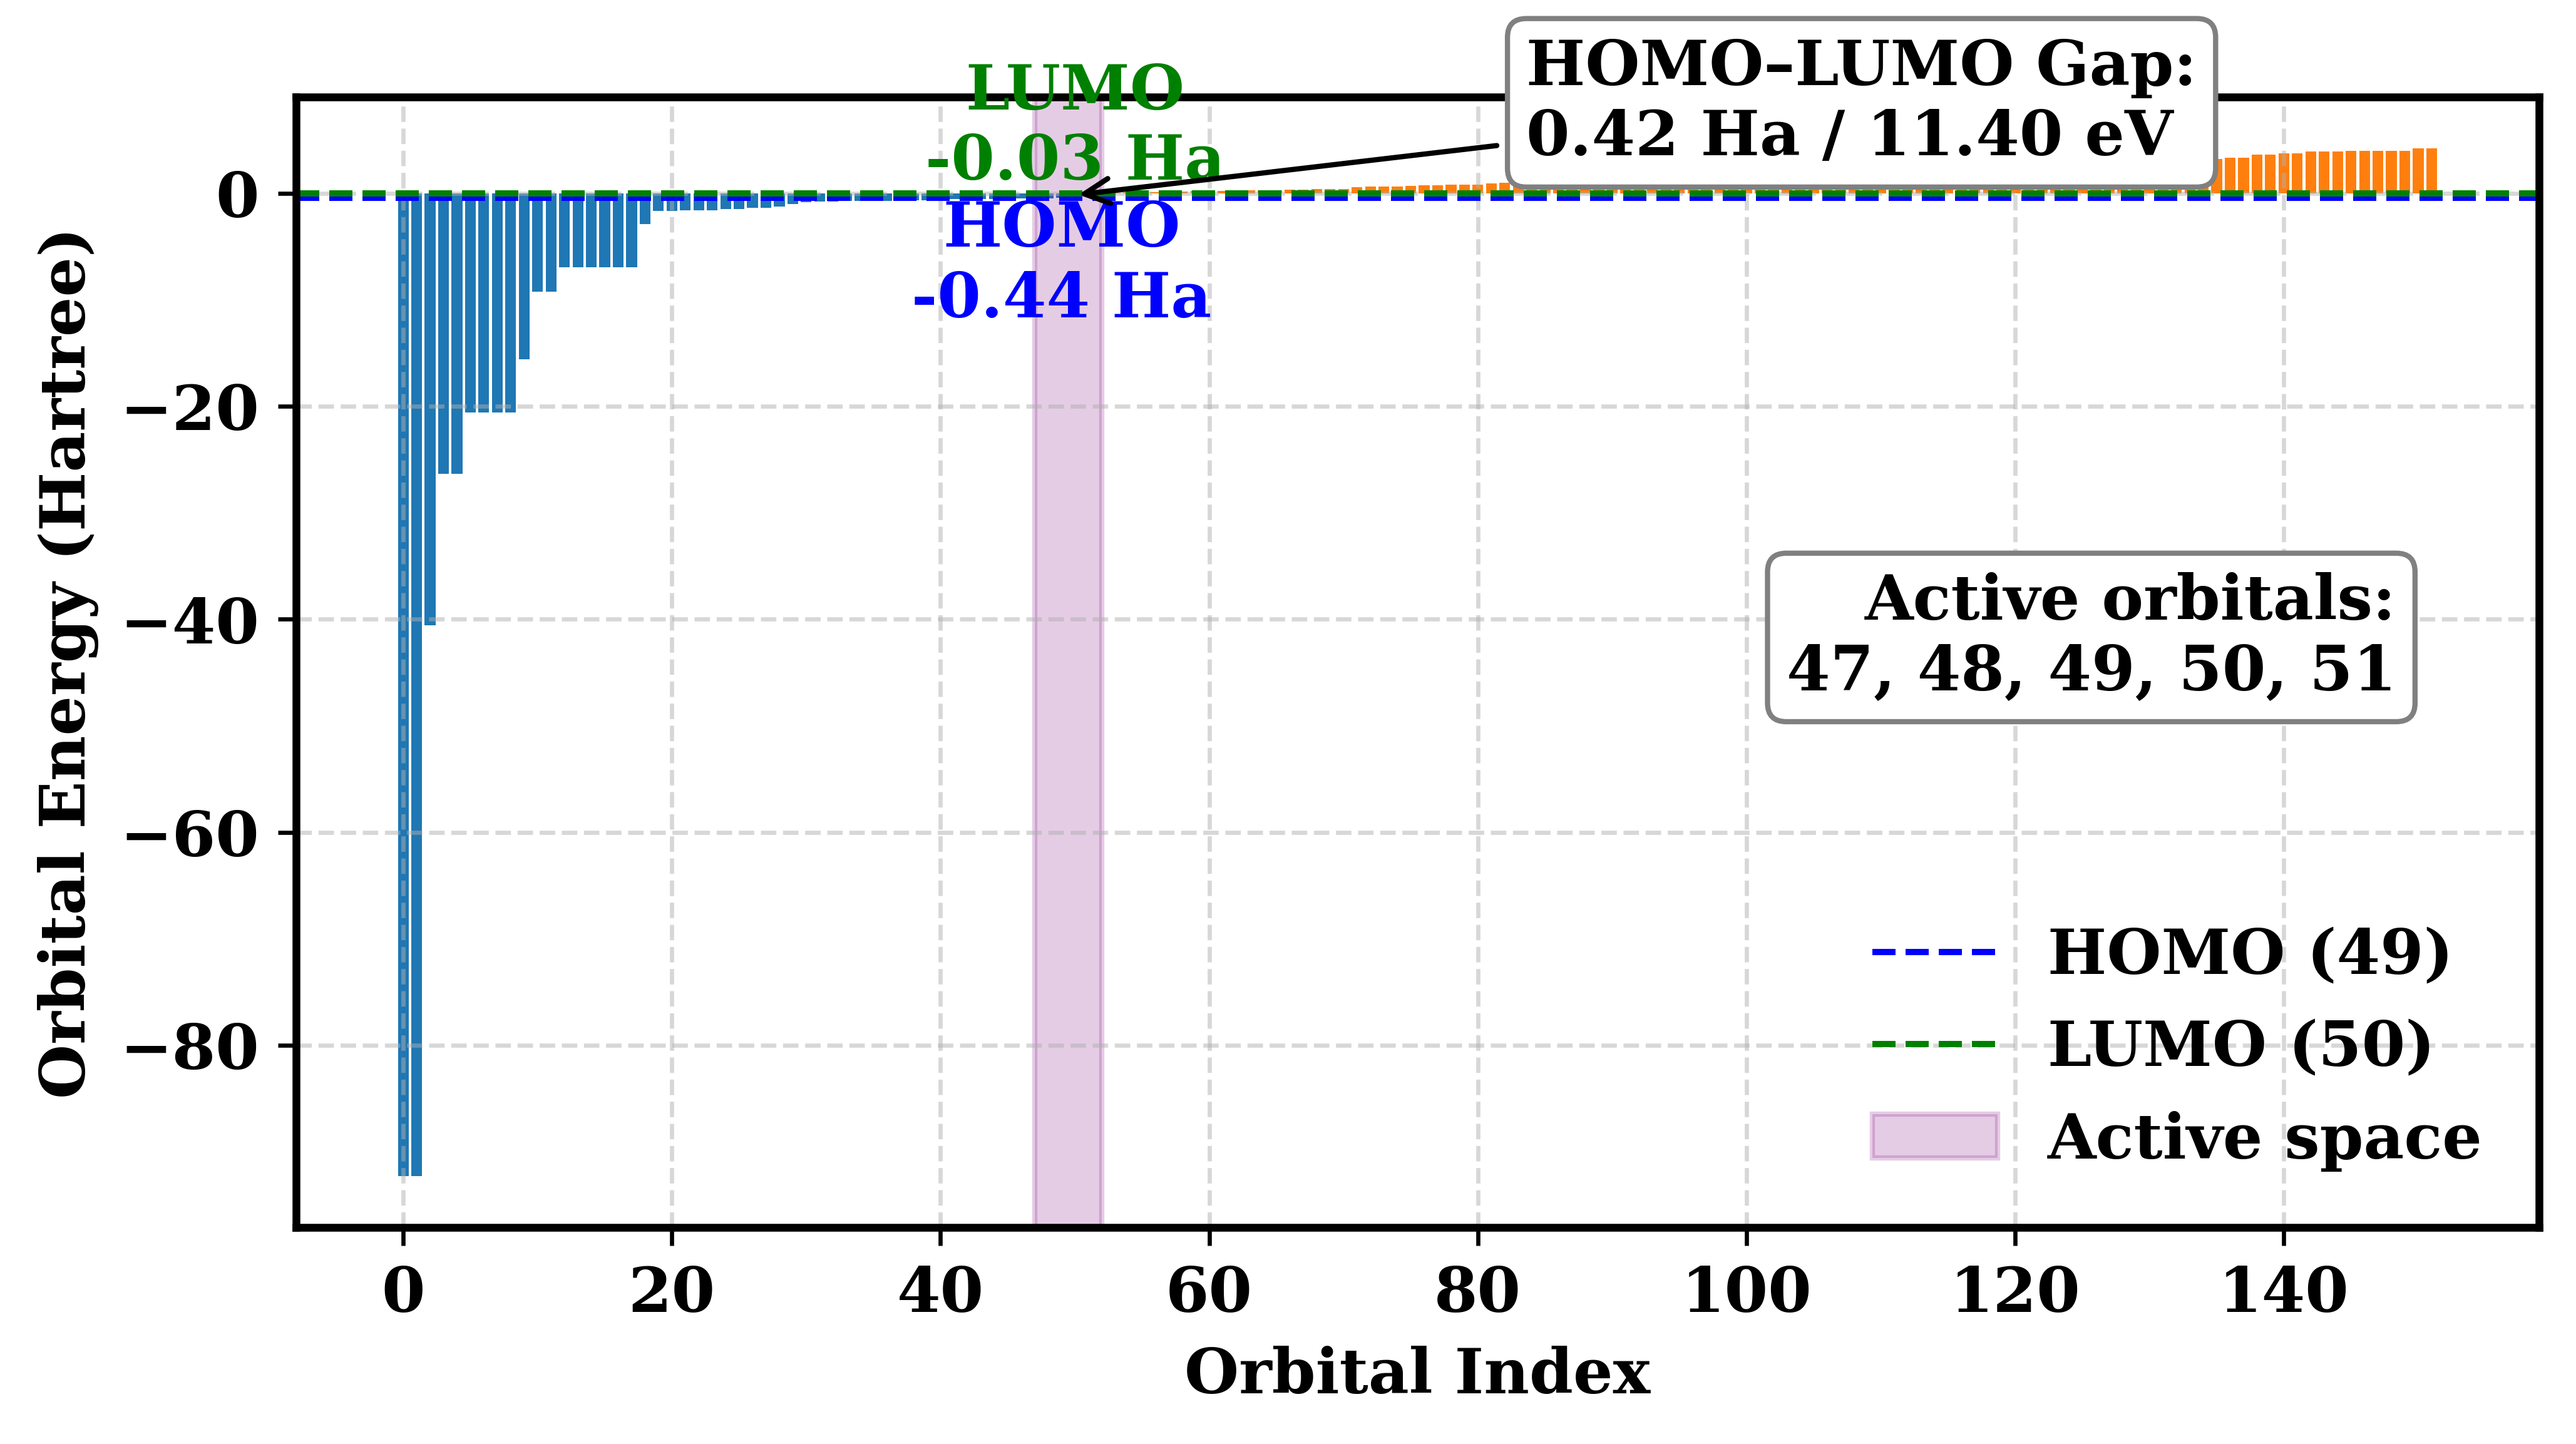

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import matplotlib as mpl

# ───────────────────────────────────────────────
# Global styling: Times New Roman, 600 DPI
# ───────────────────────────────────────────────
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 600,
    'savefig.dpi': 600
})

# ───────────────────────────────────────────────
# Inputs from PySCF or dummy data for testing
# ───────────────────────────────────────────────
# Replace with:
mo_energies = mf.mo_energy
n_electrons = mol.nelectron

#mo_energies = np.sort(np.random.uniform(-1.5, 1.5, 80))  # Placeholder energies
#n_electrons = 78  # Closed-shell system with 39 occupied orbitals

# ───────────────────────────────────────────────
# HOMO & LUMO detection
# ───────────────────────────────────────────────
homo = n_electrons // 2 - 1
lumo = homo + 1
homo_energy = mo_energies[homo]
lumo_energy = mo_energies[lumo]
gap_ha = lumo_energy - homo_energy
gap_ev = gap_ha * 27.2114  # Ha → eV

# ───────────────────────────────────────────────
# Active space definition (HOMO ± window)
# ───────────────────────────────────────────────
window = 2
active_start = max(homo - window, 0)
active_end = min(lumo + window, len(mo_energies) - 1)
active_orbitals = list(range(active_start, active_end))

# ───────────────────────────────────────────────
# Plotting
# ───────────────────────────────────────────────
plt.figure(figsize=(7, 4))

# Color bars: occupied (blue), virtual (orange)
colors = ['tab:blue' if i <= homo else 'tab:orange' for i in range(len(mo_energies))]
plt.bar(range(len(mo_energies)), mo_energies, color=colors)

# Draw HOMO and LUMO lines
plt.axhline(homo_energy, color='blue', linestyle='--', linewidth=1.2, label=f'HOMO ({homo})')
plt.axhline(lumo_energy, color='green', linestyle='--', linewidth=1.2, label=f'LUMO ({lumo})')

# Shade active space
plt.axvspan(active_start, active_end, color='purple', alpha=0.2,
            label=f'Active space')# (HOMO±{window})')

# Annotate HOMO and LUMO
plt.text(homo, homo_energy - 0.1, f'HOMO\n{homo_energy:.2f} Ha',
         ha='center', va='top', fontsize=12, color='blue', fontweight='bold')
plt.text(lumo, lumo_energy + 0.1, f'LUMO\n{lumo_energy:.2f} Ha',
         ha='center', va='bottom', fontsize=12, color='green', fontweight='bold')

# Annotate HOMO–LUMO gap
plt.annotate(f"HOMO–LUMO Gap:\n{gap_ha:.2f} Ha / {gap_ev:.2f} eV",
             xy=((homo + lumo) / 2, (homo_energy + lumo_energy) / 2),
             xytext=(len(mo_energies) * 0.55, max(mo_energies) * 0.85),
             arrowprops=dict(arrowstyle="->", color='black'),
             bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray"),
             fontsize=12, fontweight='bold')

# Wrap active orbitals into multiple lines (8 per line)
lines = [", ".join(map(str, active_orbitals[i:i+8]))
         for i in range(0, len(active_orbitals), 8)]
wrapped_text = "\n".join(lines)

# Add active orbital indices inside the plot (top-right)
plt.gcf().text(0.92, 0.6,
               f"Active orbitals:\n{wrapped_text}",
               ha='right', va='top',
               fontsize=12,
               fontweight='bold',
               bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray"))

# Final plot settings
plt.xlabel('Orbital Index', fontsize=12, fontweight='bold')
plt.ylabel('Orbital Energy (Hartree)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(prop=FontProperties(weight='bold', size=12), frameon=False)
plt.tight_layout()

# === Axis Border Thickness ===
ax = plt.gca()
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# === Axis Tick Styling ===
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# Save and show
plt.savefig("NaFSI_orbital_energy_active_space.jpg", format='jpg', dpi=600, bbox_inches='tight')
plt.show()

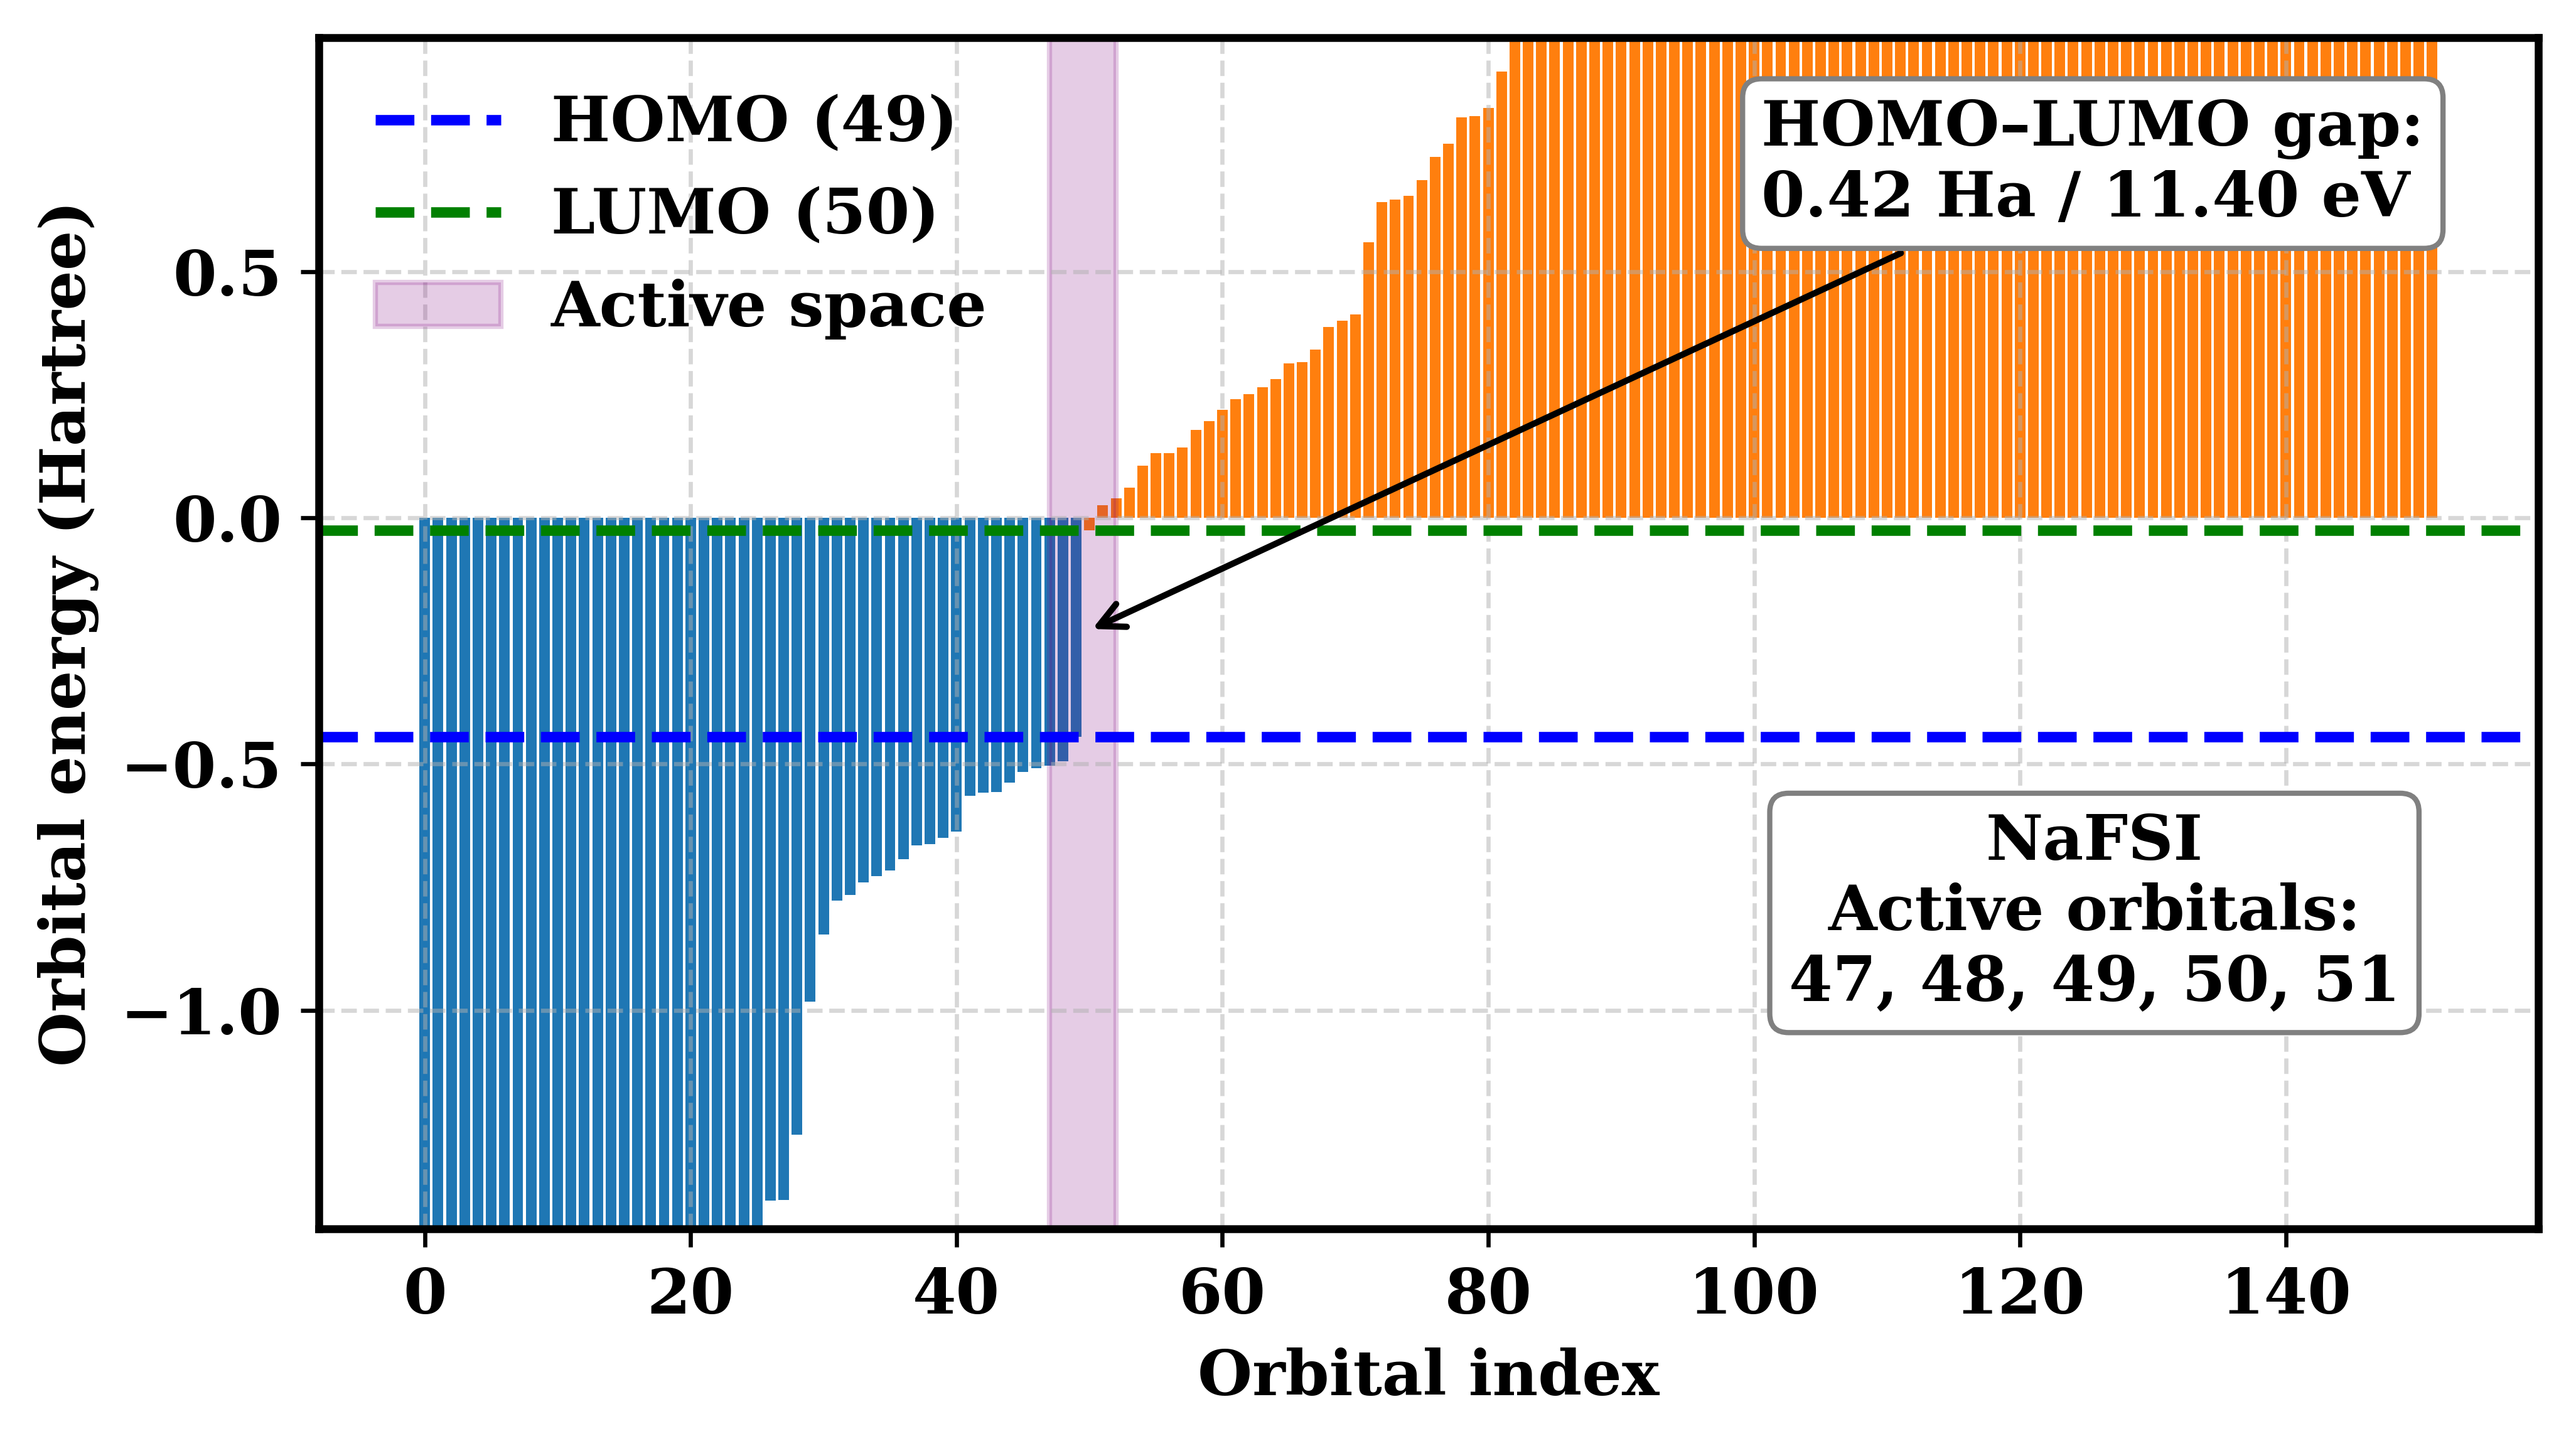

In [6]:
# Zoom window around HOMO–LUMO ± ~1 Ha
zoom_lower = homo_energy - 1.0
zoom_upper = lumo_energy + 1.0

plt.figure(figsize=(7,4))

# Bars
plt.bar(range(len(mo_energies)), mo_energies, color=colors)

# HOMO / LUMO reference lines WITH indices
plt.axhline(homo_energy, color='blue', linestyle='--', linewidth=2.0,
            label=f'HOMO ({homo})')
plt.axhline(lumo_energy, color='green', linestyle='--', linewidth=2.0,
            label=f'LUMO ({lumo})')


# ---- Annotate HOMO–LUMO gap ----
gap_ha = lumo_energy - homo_energy
gap_ev = gap_ha * 27.2114  # Hartree → eV

plt.annotate(
    f"HOMO–LUMO gap:\n{gap_ha:.2f} Ha / {gap_ev:.2f} eV",
    xy=((homo + lumo) / 2, (homo_energy + lumo_energy) / 2),
    xytext=(0.65, 0.85),
    textcoords='axes fraction',
    arrowprops=dict(arrowstyle="->", linewidth=1.2),
    fontsize=12,
    fontweight='bold',
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
)


# Active space shading
plt.axvspan(active_start, active_end, color='purple', alpha=0.2,
            label='Active space')

# Axis limits
plt.ylim(zoom_lower, zoom_upper)

# Axis labels
plt.xlabel("Orbital index", fontweight='bold')
plt.ylabel("Orbital energy (Hartree)", fontweight='bold')

# Title
#plt.title("(b) Zoomed view around active space", fontweight='bold')

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# ---- Explicit annotation of active orbital indices ----
active_orbital_text = ", ".join(map(str, active_orbitals))

plt.text(
    0.8, 0.35,
    f"NaFSI\nActive orbitals:\n{active_orbital_text}",
    #f"Active orbitals:\n{active_orbital_text}",
    transform=plt.gca().transAxes,
    ha='center', va='top',
    fontsize=12, fontweight='bold',
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
)

# Legend
plt.legend(frameon=False, fontsize=11, prop=FontProperties(weight='bold'))

# === Axis Border Thickness ===
ax = plt.gca()
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# === Axis Tick Styling ===
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')


plt.tight_layout()
plt.savefig("NaFSI_orbital_energy_active_space_new.jpg", format='jpg',
            dpi=600, bbox_inches='tight')
plt.show()


In [3]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.circuit.library import EfficientSU2
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA
from qiskit.primitives import Estimator


# Step 1: Geometry for LiFSI
nafsi_geometry = (
    "N  0.0000  0.0000  0.2798; "
    "S  0.0000  1.4406 -0.4595; "
    "O  1.2581  1.8123 -1.0595; "
    "O -1.2581  1.8123 -1.0595; "
    "F  0.0000  2.2257  1.0569; "
    "S  0.0000 -1.4406 -0.4595; "
    "O  1.2581 -1.8123 -1.0595; "
    "O -1.2581 -1.8123 -1.0595; "
    "F  0.0000 -2.2257  1.0569; "
    "Na 0.0000  0.0000  2.5117"
)

# === Step 1: Define the LiFSI molecule ===
driver = PySCFDriver(
    atom= nafsi_geometry,
    basis="631g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM
)
es_problem = driver.run()

print("Spatial orbitals :", es_problem.num_spatial_orbitals)
print("Spin Orbitals", es_problem.num_spin_orbitals)
# How many physical electrons (α + β)?
n_alpha, n_beta = es_problem.num_particles
print("Electrons        :", n_alpha + n_beta, f"({n_alpha} α, {n_beta} β)")
no_of_qubit = 2*es_problem.num_spatial_orbitals
print("Number Qubit needed :", no_of_qubit)

# === Step 2: Freeze core + remove high-energy virtuals ===
freeze_transformer = FreezeCoreTransformer(
    freeze_core=list(range(0, 47)),   # Core
    remove_orbitals=list(range(52, es_problem.num_spatial_orbitals))            # Virtual
)
es_problem_reduced = freeze_transformer.transform(es_problem)

# === Step 3: Reduce active space (adjust electrons/orbitals as needed) ===
active_transformer = ActiveSpaceTransformer(
    num_electrons=6,
    num_spatial_orbitals=4          # 3 orbitals × 2 = 6 qubits
)
es_problem_active = active_transformer.transform(es_problem_reduced)

# === Step 4: Build qubit Hamiltonian ===
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(es_problem_active.second_q_ops()[0])
num_particles = es_problem_active.num_particles
num_spatial_orbitals = es_problem_active.num_spatial_orbitals

# === Step 5: Ansatz and initial state ===
init_state = HartreeFock(num_spatial_orbitals, num_particles, mapper)
ansatz = UCCSD(num_spatial_orbitals, num_particles, mapper, initial_state=init_state)
#ansatz = EfficientSU2(qubit_hamiltonian.num_qubits)

# === Step 6: VQE setup ===
#optimizer = SLSQP(maxiter=1000)
optimizer = COBYLA(maxiter=10000)
estimator = Estimator()

vqe_solver = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer)
vqe_solver.initial_point = [0.0] * ansatz.num_parameters

solver = GroundStateEigensolver(mapper, vqe_solver)
result = solver.solve(es_problem_active)

# === Step 7: Output results ===
print("\n Molecule: NaFSI (active space)")
print(" Qubits used:", qubit_hamiltonian.num_qubits)
print("Particles:", num_particles)
print("Spatial Orbitals:", num_spatial_orbitals)
print("Ground state energy (Hartree):", result.total_energies[0].real)
print("Optimal parameters:", result.raw_result.optimal_point)

# Optional: visualize ansatz
#ansatz.assign_parameters(result.raw_result.optimal_point).decompose(reps=3).draw("mpl", style="iqp")

Spatial orbitals : 102
Spin Orbitals 204
Electrons        : 100 (50 α, 50 β)
Number Qubit needed : 204

 Molecule: NaFSI (active space)
 Qubits used: 8
Particles: (3, 3)
Spatial Orbitals: 4
Ground state energy (Hartree): -1508.7768418350993
Optimal parameters: [ 2.31830737e-05 -4.28419085e-05  4.80528172e-05  5.24765814e-05
  2.38082803e-05  5.97179504e-05 -9.24329888e-06 -7.87735371e-06
  2.57983465e-05  8.95579571e-06 -5.28645669e-04 -1.11342796e-05
 -6.12897876e-06 -1.86312284e-05 -2.54647042e-04]


In [7]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.circuit.library import EfficientSU2
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA
from qiskit.primitives import Estimator


# Step 1: Geometry for NaFSI
nafsi_geometry = (
    "N  0.0000  0.0000  0.2798; "
    "S  0.0000  1.4406 -0.4595; "
    "O  1.2581  1.8123 -1.0595; "
    "O -1.2581  1.8123 -1.0595; "
    "F  0.0000  2.2257  1.0569; "
    "S  0.0000 -1.4406 -0.4595; "
    "O  1.2581 -1.8123 -1.0595; "
    "O -1.2581 -1.8123 -1.0595; "
    "F  0.0000 -2.2257  1.0569; "
    "Na 0.0000  0.0000  2.5117"
)

# === Step 1: Define the NaFSI molecule ===
driver = PySCFDriver(atom=nafsi_geometry,
                     basis='cc-pVDZ', #"631g*",
                     charge=0,
                     spin=0,
                     unit=DistanceUnit.ANGSTROM)
problem = driver.run()

print("── Original HF problem ─────────────────────────")
print("Spatial orbitals :", problem.num_spatial_orbitals)
print("Spin  orbitals   :", problem.num_spin_orbitals)
na, nb = problem.num_particles
print(f"Electrons        : {na+nb} ({na} α, {nb} β)\n")

# ──────────────────────────────────────────────────────────────────────────────
# 2.  Freeze‑core + trim high‑energy virtuals
# ──────────────────────────────────────────────────────────────────────────────
freeze_core     = list(range(0, 45))                            # lowest 22 MOs
remove_orbitals = list(range(53, problem.num_spatial_orbitals)) # 29 … 75

fc = FreezeCoreTransformer(freeze_core=False,
                           remove_orbitals=remove_orbitals+freeze_core)
problem_red = fc.transform(problem)

# Show what survived this step
all_orbs     = set(range(problem.num_spatial_orbitals))
frozen_orbs  = set(freeze_core)
removed_orbs = set(remove_orbitals)
kept_fc      = sorted(all_orbs - frozen_orbs - removed_orbs)

print("── After FreezeCoreTransformer ────────────────")
print("Frozen orbitals   :", sorted(freeze_core))
print("Removed virtuals  :", sorted(remove_orbitals))
print("Kept orbitals     :", kept_fc)
print("Spatial orbitals  :", problem_red.num_spatial_orbitals, "\n")
na, nb = problem_red.num_particles
print(f"Electrons        : {na+nb} ({na} α, {nb} β)\n")

# ──────────────────────────────────────────────────────────────────────────────
# 3.  Active‑space reduction (6 e⁻ in 4 MOs)
# ──────────────────────────────────────────────────────────────────────────────
# Choose which of the kept orbitals will be active.
# Example below: take the first four kept orbitals (indices 0,1,2,3 in problem_red).
active_orbs_reduced = [2, 3, 4, 5, 6]          # change if you prefer a different window
ast = ActiveSpaceTransformer(
    num_electrons=6,
    num_spatial_orbitals=5,
    active_orbitals=active_orbs_reduced
)
problem_act = ast.transform(problem_red)

# Map those active indices back to original PySCF numbering
active_original = [kept_fc[i] for i in active_orbs_reduced]

print("── Active space ───────────────────────────────")
print("Active orbitals (re‑indexed) :", active_orbs_reduced)
print("Active orbitals (original HF):", active_original)
print("Spatial orbitals              :", problem_act.num_spatial_orbitals)
na, nb = problem_act.num_particles
print(f"Electrons                     : {na+nb} ({na} α, {nb} β)\n")

# ──────────────────────────────────────────────────────────────────────────────
# 4.  Qubit mapping, ansatz, VQE
# ──────────────────────────────────────────────────────────────────────────────
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(problem_act.second_q_ops()[0])

init_state = HartreeFock(problem_act.num_spatial_orbitals,
                         problem_act.num_particles, mapper)
ansatz = UCCSD(problem_act.num_spatial_orbitals,
               problem_act.num_particles, mapper,
               initial_state=init_state)

vqe = VQE(estimator=Estimator(),
          ansatz=ansatz,
          optimizer=COBYLA(maxiter=10000))
vqe.initial_point = [0.0] * ansatz.num_parameters

gs_solver = GroundStateEigensolver(mapper, vqe)
result = gs_solver.solve(problem_act)

print("── VQE result ────────────────────────────────")
print("Qubits used          :", qubit_hamiltonian.num_qubits)
print("Ground‑state energy  :", result.total_energies[0].real, "Ha")
print("Optimal parameters   :", result.raw_result.optimal_point)

# Optional: visualize ansatz
#ansatz.assign_parameters(result.raw_result.optimal_point).decompose(reps=3).draw("mpl", style="iqp")

── Original HF problem ─────────────────────────
Spatial orbitals : 152
Spin  orbitals   : 304
Electrons        : 100 (50 α, 50 β)

── After FreezeCoreTransformer ────────────────
Frozen orbitals   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44]
Removed virtuals  : [53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151]
Kept orbitals     : [45, 46, 47, 48, 49, 50, 51, 52]
Spatial orbitals  : 8 

Electrons        : 10 (5 α, 5 β)

── Active space ───────────────────────────────
A

Distance: 1.5000 Å, Energy: -1508.945825 Ha
Distance: 1.7647 Å, Energy: -1509.355448 Ha
Distance: 2.0294 Å, Energy: -1509.504284 Ha
Distance: 2.2941 Å, Energy: -1509.549147 Ha
Distance: 2.5117 Å, Energy: -1509.555741 Ha
Distance: 2.5588 Å, Energy: -1509.555454 Ha
Distance: 2.8235 Å, Energy: -1509.548404 Ha
Distance: 3.0882 Å, Energy: -1509.537417 Ha
Distance: 3.3529 Å, Energy: -1509.525941 Ha
Distance: 3.6176 Å, Energy: -1509.515152 Ha
Distance: 3.8824 Å, Energy: -1509.505374 Ha
Distance: 4.1471 Å, Energy: -1509.496629 Ha
Distance: 4.4118 Å, Energy: -1509.488845 Ha
Distance: 4.6765 Å, Energy: -1509.481941 Ha
Distance: 4.9412 Å, Energy: -1509.475838 Ha
Distance: 5.2059 Å, Energy: -1509.470448 Ha
Distance: 5.4706 Å, Energy: -1509.465673 Ha
Distance: 5.7353 Å, Energy: -1509.461406 Ha
Distance: 6.0000 Å, Energy: -1509.457553 Ha


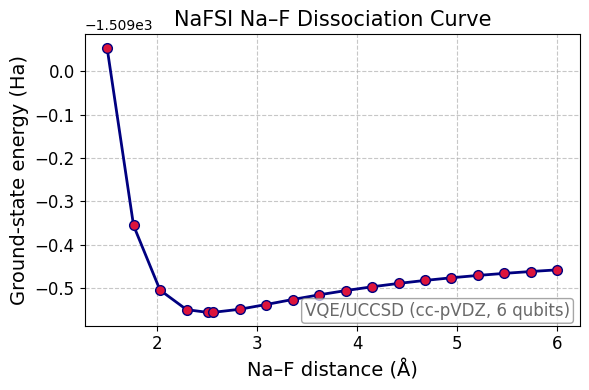

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# Na–F dissociation distances: include 2.5117 Å exactly
lf_distances = np.array(sorted(set(np.append(np.linspace(1.5, 6.0, 18), [2.5117]))))
vqe_energies = []
qubit_count = None
basis_set = 'cc-pVDZ'

for d in lf_distances:
    nafsi_geometry = (
        f"N  0.0000  0.0000  0.2798; "
        f"S  0.0000  1.4406 -0.4595; "
        f"O  1.2581  1.8123 -1.0595; "
        f"O -1.2581  1.8123 -1.0595; "
        f"F  0.0000  2.2257  1.0569; "
        f"S  0.0000 -1.4406 -0.4595; "
        f"O  1.2581 -1.8123 -1.0595; "
        f"O -1.2581 -1.8123 -1.0595; "
        f"F  0.0000 -2.2257  1.0569; "
        f"Na 0.0000  0.0000  {d:8.6f}"
    )
    driver = PySCFDriver(atom=nafsi_geometry,
                         basis=basis_set,
                         charge=0,
                         spin=0,
                         unit=DistanceUnit.ANGSTROM)
    problem = driver.run()
    freeze_core     = list(range(0, 45))
    remove_orbitals = list(range(53, problem.num_spatial_orbitals))
    fc = FreezeCoreTransformer(freeze_core=False,
                               remove_orbitals=remove_orbitals+freeze_core)
    problem_red = fc.transform(problem)
    all_orbs     = set(range(problem.num_spatial_orbitals))
    frozen_orbs  = set(freeze_core)
    removed_orbs = set(remove_orbitals)
    kept_fc      = sorted(all_orbs - frozen_orbs - removed_orbs)
    active_orbs_reduced = [3, 4, 5]
    ast = ActiveSpaceTransformer(
        num_electrons=4,
        num_spatial_orbitals=3,
        active_orbitals=active_orbs_reduced
    )
    problem_act = ast.transform(problem_red)
    mapper = JordanWignerMapper()
    qubit_hamiltonian = mapper.map(problem_act.second_q_ops()[0])
    if qubit_count is None:
        qubit_count = qubit_hamiltonian.num_qubits
    init_state = HartreeFock(problem_act.num_spatial_orbitals,
                             problem_act.num_particles, mapper)
    ansatz = UCCSD(problem_act.num_spatial_orbitals,
                   problem_act.num_particles, mapper,
                   initial_state=init_state)
    vqe = VQE(estimator=Estimator(),
              ansatz=ansatz,
              optimizer=COBYLA(maxiter=10000))
    vqe.initial_point = [0.0] * ansatz.num_parameters
    gs_solver = GroundStateEigensolver(mapper, vqe)
    result = gs_solver.solve(problem_act)
    energy = result.total_energies[0].real
    vqe_energies.append(energy)
    print(f"Distance: {d:.4f} Å, Energy: {energy:.6f} Ha")

# Save bond distances and energies to a .dat file
with open("NaFSI_dissociation_energies.dat", "w") as f:
    f.write("# Na–F bond distance (Å)    Ground-state energy (Ha)\n")
    for d, e in zip(lf_distances, vqe_energies):
        f.write(f"{d:8.4f}\t{e: .8f}\n")

# Publication-quality plot
plt.figure(figsize=(6, 4))
plt.plot(lf_distances, vqe_energies, '-o', color='navy', markerfacecolor='crimson', markersize=7, linewidth=2)
plt.xlabel('Na–F distance (Å)', fontsize=14)
plt.ylabel('Ground-state energy (Ha)', fontsize=14)
plt.title('NaFSI Na–F Dissociation Curve', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
# Add basis set and qubit count as annotation inside the plot
plt.annotate(f'VQE/UCCSD ({basis_set}, {qubit_count} qubits)', xy=(0.98, 0.02), xycoords='axes fraction', fontsize=12, color='dimgray', ha='right', va='bottom', bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.7))
plt.tight_layout()
plt.savefig('NaFSI_Na-F_dissociation_curve.png', dpi=600, bbox_inches='tight')
plt.show()

In [4]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_nature.second_q.algorithms import QEOM, EvaluationRule
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# === Step 1: Molecule Geometry ===
nafsi_geometry = (
    "N  0.0000  0.0000  0.2798; "
    "S  0.0000  1.4406 -0.4595; "
    "O  1.2581  1.8123 -1.0595; "
    "O -1.2581  1.8123 -1.0595; "
    "F  0.0000  2.2257  1.0569; "
    "S  0.0000 -1.4406 -0.4595; "
    "O  1.2581 -1.8123 -1.0595; "
    "O -1.2581 -1.8123 -1.0595; "
    "F  0.0000 -2.2257  1.0569; "
    "Na 0.0000  0.0000  2.5117"
)

driver = PySCFDriver(
    atom=nafsi_geometry,
    basis="631g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM
)
es_problem = driver.run()

# === Step 2: Freeze core + reduce orbitals ===
freeze_transformer = FreezeCoreTransformer(
    freeze_core=list(range(0, 47)),
    remove_orbitals=list(range(52, es_problem.num_spatial_orbitals))
)
es_problem_reduced = freeze_transformer.transform(es_problem)

# === Step 3: Active space ===
active_transformer = ActiveSpaceTransformer(num_electrons=6, num_spatial_orbitals=4)
es_problem_active = active_transformer.transform(es_problem_reduced)

# === Step 4: Qubit mapping ===
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(es_problem_active.second_q_ops()[0])
num_particles = es_problem_active.num_particles
num_spatial_orbitals = es_problem_active.num_spatial_orbitals

# === Step 5: Ansatz ===
init_state = HartreeFock(num_spatial_orbitals, num_particles, mapper)
ansatz = UCCSD(num_spatial_orbitals, num_particles, mapper, initial_state=init_state)

# === Step 6: VQE Ground State Solver ===
optimizer = COBYLA(maxiter=10000)
estimator = Estimator()
vqe_solver = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer)
vqe_solver.initial_point = [0.0] * ansatz.num_parameters

g_solver = GroundStateEigensolver(mapper, vqe_solver)

# === Step 7: Excited State Solver using qEOM ===
qeom_solver = QEOM(g_solver, estimator, "sd", EvaluationRule.DIAG)  # Use both single and double excitations
result = qeom_solver.solve(es_problem_active)

# === Step 8: Print Results ===
print("\n=== NaFSI Excited State Energies ===")
energies = [res.real for res in result.total_energies]
ground_state_energy = energies[0]

for i, energy in enumerate(energies):
    label = "Ground" if i == 0 else f"Excited {i}"
    delta_E = energy - ground_state_energy if i > 0 else 0
    print(f"{label} State Energy: {energy:.6f} Hartree", end="")
    if i > 0:
        print(f"   ΔE = {delta_E:.6f} Hartree ≈ {delta_E*27.2114:.2f} eV")
    else:
        print()


=== NaFSI Excited State Energies ===
Ground State Energy: -1508.776842 Hartree
Excited 1 State Energy: -1508.422931 Hartree   ΔE = 0.353911 Hartree ≈ 9.63 eV
Excited 2 State Energy: -1508.422425 Hartree   ΔE = 0.354417 Hartree ≈ 9.64 eV
Excited 3 State Energy: -1508.406577 Hartree   ΔE = 0.370265 Hartree ≈ 10.08 eV
Excited 4 State Energy: -1508.405729 Hartree   ΔE = 0.371113 Hartree ≈ 10.10 eV
Excited 5 State Energy: -1508.370763 Hartree   ΔE = 0.406079 Hartree ≈ 11.05 eV
Excited 6 State Energy: -1508.370616 Hartree   ΔE = 0.406226 Hartree ≈ 11.05 eV
Excited 7 State Energy: -1507.794657 Hartree   ΔE = 0.982185 Hartree ≈ 26.73 eV
Excited 8 State Energy: -1507.781890 Hartree   ΔE = 0.994952 Hartree ≈ 27.07 eV
Excited 9 State Energy: -1507.776739 Hartree   ΔE = 1.000103 Hartree ≈ 27.21 eV
Excited 10 State Energy: -1507.776337 Hartree   ΔE = 1.000505 Hartree ≈ 27.23 eV
Excited 11 State Energy: -1507.766618 Hartree   ΔE = 1.010224 Hartree ≈ 27.49 eV
Excited 12 State Energy: -1507.751757 Ha

In [5]:
from qiskit_nature.second_q.algorithms import GroundStateEigensolver, QEOM, ExcitedStatesEigensolver
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.units import DistanceUnit
from qiskit_algorithms import NumPyEigensolver, VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit.primitives import Estimator
from qiskit_nature.second_q.algorithms import EvaluationRule

# === Step 1: Geometry and driver ===
nafsi_geometry = (
    "N  0.0000  0.0000  0.2798; "
    "S  0.0000  1.4406 -0.4595; "
    "O  1.2581  1.8123 -1.0595; "
    "O -1.2581  1.8123 -1.0595; "
    "F  0.0000  2.2257  1.0569; "
    "S  0.0000 -1.4406 -0.4595; "
    "O  1.2581 -1.8123 -1.0595; "
    "O -1.2581 -1.8123 -1.0595; "
    "F  0.0000 -2.2257  1.0569; "
    "Na 0.0000  0.0000  2.5117"
)

driver = PySCFDriver(atom=nafsi_geometry, basis="631g", charge=0, spin=0, unit=DistanceUnit.ANGSTROM)
es_problem = driver.run()

# === Step 2: Transform for active space ===
es_problem_reduced = FreezeCoreTransformer(
    freeze_core=list(range(0, 47)),
    remove_orbitals=list(range(52, es_problem.num_spatial_orbitals))
).transform(es_problem)

es_problem_active = ActiveSpaceTransformer(
    num_electrons=6,
    num_spatial_orbitals=4
).transform(es_problem_reduced)

mapper = JordanWignerMapper()

# === Step 3: Classical exact eigensolver ===
numpy_solver = NumPyEigensolver(k=8)
numpy_excited_solver = ExcitedStatesEigensolver(mapper, numpy_solver)
numpy_results = numpy_excited_solver.solve(es_problem_active)

# === Step 4: VQE + QEOM ===
estimator = Estimator()
ansatz = UCCSD(
    es_problem_active.num_spatial_orbitals,
    es_problem_active.num_particles,
    mapper,
    initial_state=HartreeFock(
        es_problem_active.num_spatial_orbitals,
        es_problem_active.num_particles,
        mapper,
    ),
)
vqe_solver = VQE(estimator, ansatz, SLSQP())
vqe_solver.initial_point = [0.0] * ansatz.num_parameters

gse = GroundStateEigensolver(mapper, vqe_solver)
qeom_solver = QEOM(gse, estimator, "sd", EvaluationRule.ALL)
qeom_results = qeom_solver.solve(es_problem_active)

# === Step 5: Compare Results ===
print("\n=== NumPy (Exact) Excited State Energies of NaFSI ===")
for i, e in enumerate(numpy_results.total_energies):
    print(f"State {i}: {e.real:.6f} Hartree")

print("\n=== VQE + qEOM Excited State Energies of NaFSI ===")
gs_energy = qeom_results.total_energies[0].real
for i, e in enumerate(qeom_results.total_energies):
    label = "Ground" if i == 0 else f"Excited {i}"
    delta_e = e.real - gs_energy if i > 0 else 0
    print(f"{label} State: {e.real:.6f} Hartree", end="")
    if i > 0:
        print(f"   ΔE = {delta_e:.6f} Hartree ≈ {delta_e * 27.2114:.2f} eV")
    else:
        print()

bandgap = qeom_results.computed_energies[1] - qeom_results.computed_energies[0]
print("\n=== HOMO and LUMO gap of NaFSI ===")
print(f" ΔE_gap = {bandgap:.6f} Hartree ≈ {bandgap * 27.2114:.2f} eV")
#bandgap # in Hartree



=== NumPy (Exact) Excited State Energies of NaFSI ===
State 0: -1508.802113 Hartree
State 1: -1508.802113 Hartree
State 2: -1508.776842 Hartree
State 3: -1508.622717 Hartree
State 4: -1508.422931 Hartree
State 5: -1508.422931 Hartree
State 6: -1508.422931 Hartree
State 7: -1508.422424 Hartree

=== VQE + qEOM Excited State Energies of NaFSI ===
Ground State: -1508.776842 Hartree
Excited 1 State: -1508.422931 Hartree   ΔE = 0.353911 Hartree ≈ 9.63 eV
Excited 2 State: -1508.422424 Hartree   ΔE = 0.354418 Hartree ≈ 9.64 eV
Excited 3 State: -1508.406577 Hartree   ΔE = 0.370265 Hartree ≈ 10.08 eV
Excited 4 State: -1508.405728 Hartree   ΔE = 0.371113 Hartree ≈ 10.10 eV
Excited 5 State: -1508.370763 Hartree   ΔE = 0.406079 Hartree ≈ 11.05 eV
Excited 6 State: -1508.370616 Hartree   ΔE = 0.406226 Hartree ≈ 11.05 eV
Excited 7 State: -1507.794657 Hartree   ΔE = 0.982185 Hartree ≈ 26.73 eV
Excited 8 State: -1507.781890 Hartree   ΔE = 0.994951 Hartree ≈ 27.07 eV
Excited 9 State: -1507.776739 Hartre

Running VQE at Na–F distance 1.50 Å ...
Running VQE at Na–F distance 1.76 Å ...
Running VQE at Na–F distance 2.03 Å ...
Running VQE at Na–F distance 2.29 Å ...
Running VQE at Na–F distance 2.56 Å ...
Running VQE at Na–F distance 2.82 Å ...
Running VQE at Na–F distance 3.09 Å ...
Running VQE at Na–F distance 3.35 Å ...
Running VQE at Na–F distance 3.62 Å ...
Running VQE at Na–F distance 3.88 Å ...
Running VQE at Na–F distance 4.15 Å ...
Running VQE at Na–F distance 4.41 Å ...
Running VQE at Na–F distance 4.68 Å ...
Running VQE at Na–F distance 4.94 Å ...
Running VQE at Na–F distance 5.21 Å ...
Running VQE at Na–F distance 5.47 Å ...
Running VQE at Na–F distance 5.74 Å ...
Running VQE at Na–F distance 6.00 Å ...

✅ Saved minimum-energy geometry to NaFSI_min.xyz


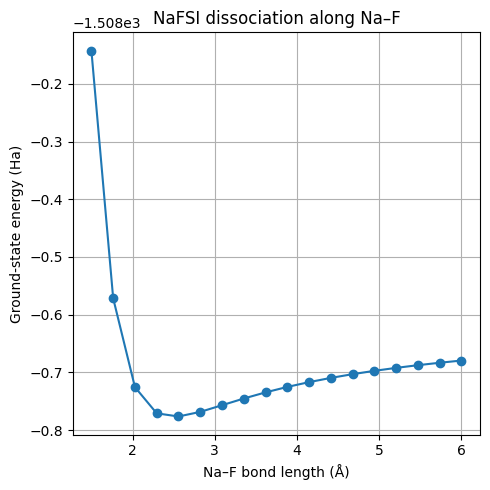

In [10]:
###############################################################
# Na–F dissociation curve with VQE (active‑space UCCSD)
###############################################################
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# ---------------- USER SETTINGS -----------------
basis                 = "6-31g"
freeze_core_list      = list(range(0, 47))
virtual_trim_start    = 52
active_nelec          = 6
active_norb           = 4
optimizer_maxiter     = 10000
distances             = np.linspace(1.5, 6.0, 18)   # 18 points → 1.5 … 6.0 Å
# ------------------------------------------------


def make_geometry(d):
    """Return NaFSI geometry string with Na along –z at distance d from P."""
    return (
        f"N  0.0000  0.0000  0.2798; "
        f"S  0.0000  1.4406 -0.4595; "
        f"O  1.2581  1.8123 -1.0595; "
        f"O -1.2581  1.8123 -1.0595; "
        f"F  0.0000  2.2257  1.0569; "
        f"S  0.0000 -1.4406 -0.4595; "
        f"O  1.2581 -1.8123 -1.0595; "
        f"O -1.2581 -1.8123 -1.0595; "
        f"F  0.0000 -2.2257  1.0569; "
        f"Na 0.0000  0.0000  {d:7.4f}"
    )


def vqe_energy(geom):
    """Return VQE ground‑state energy for a given geometry."""
    driver = PySCFDriver(atom=geom, basis=basis, unit=DistanceUnit.ANGSTROM)
    prob = driver.run()

    # Freeze core and trim virtuals
    freeze = FreezeCoreTransformer(
        freeze_core=freeze_core_list,
        remove_orbitals=list(range(virtual_trim_start, prob.num_spatial_orbitals)),
    )
    prob = freeze.transform(prob)

    # Active space
    active = ActiveSpaceTransformer(
        num_electrons=active_nelec, num_spatial_orbitals=active_norb
    )
    prob = active.transform(prob)

    mapper = JordanWignerMapper()
    qubit_op = mapper.map(prob.second_q_ops()[0])

    init = HartreeFock(active_norb, prob.num_particles, mapper)
    ans = UCCSD(active_norb, prob.num_particles, mapper, initial_state=init)

    vqe = VQE(
        Estimator(),
        ansatz=ans,
        optimizer=COBYLA(maxiter=optimizer_maxiter),
        initial_point=[0.0] * ans.num_parameters,
    )
    solver = GroundStateEigensolver(mapper, vqe)
    res = solver.solve(prob)
    return res.total_energies[0].real


# ---------- sweep distances ----------
energies = []
geometries = []  # keep geom strings for later
for d in distances:
    print(f"Running VQE at Na–F distance {d:4.2f} Å ...")
    geom_str = make_geometry(d)
    geometries.append(geom_str)
    energies.append(vqe_energy(geom_str))

energies = np.array(energies)

# ---------- find minimum and save XYZ ----------
idx_min = np.argmin(energies)
best_d = distances[idx_min]
best_geom = geometries[idx_min]

# Convert geom string → XYZ lines
atoms = [tok.strip() for tok in best_geom.split(";") if tok.strip()]
xyz_lines = [f"{len(atoms)}", f"NaFSI minimum @ Na–F = {best_d:.2f} Å"]
for line in atoms:
    # split "El x y z" → keep as-is (PySCF-compatible order)
    xyz_lines.append(line.replace("  ", " ").replace(" ;", ""))

xyz_path = Path("NaFSI_min.xyz")
xyz_path.write_text("\n".join(xyz_lines))
print(f"\n✅ Saved minimum-energy geometry to {xyz_path}")

# ---------- plot ----------
plt.figure(figsize=(5, 5))
plt.plot(distances, energies, "-o")
plt.xlabel("Na–F bond length (Å)")
plt.ylabel("Ground‑state energy (Ha)")
plt.title("NaFSI dissociation along Na–F")
plt.grid(True)
plt.tight_layout()
plt.savefig("NaFSI_Na-F_dissociation_curve.png", dpi=300)
plt.show()

In [11]:
from qiskit_nature.second_q.operators import S2
s2_op = S2()
s2_val = estimator.run(s2_op, ansatz).result().values[0]


ImportError: cannot import name 'S2' from 'qiskit_nature.second_q.operators' (/home/user/anaconda3/lib/python3.12/site-packages/qiskit_nature/second_q/operators/__init__.py)

In [15]:
pip list | grep qiskit


qiskit                            1.1.0
qiskit-aer                        0.17.0
qiskit-algorithms                 0.3.1
qiskit-ibm-runtime                0.37.0
qiskit-machine-learning           0.8.3
qiskit-nature                     0.7.2
Note: you may need to restart the kernel to use updated packages.



Running VQE dissociation curve for basis: sto3g
  Na–F = 1.50 Å : E = -1490.033004 Ha
  Na–F = 1.76 Å : E = -1490.459839 Ha
  Na–F = 2.03 Å : E = -1490.595530 Ha
  Na–F = 2.29 Å : E = -1490.621106 Ha
  Na–F = 2.51 Å : E = -1490.608947 Ha
  Na–F = 2.56 Å : E = -1490.604859 Ha
  Na–F = 2.82 Å : E = -1490.578316 Ha
  Na–F = 3.09 Å : E = -1490.553390 Ha
  Na–F = 3.35 Å : E = -1490.533994 Ha
  Na–F = 3.62 Å : E = -1490.519984 Ha
  Na–F = 3.88 Å : E = -1490.509765 Ha
  Na–F = 4.15 Å : E = -1490.501860 Ha
  Na–F = 4.41 Å : E = -1490.495331 Ha
  Na–F = 4.68 Å : E = -1490.489683 Ha
  Na–F = 4.94 Å : E = -1490.484667 Ha
  Na–F = 5.21 Å : E = -1490.480150 Ha
  Na–F = 5.47 Å : E = -1490.476049 Ha
  Na–F = 5.74 Å : E = -1490.472305 Ha
  Na–F = 6.00 Å : E = -1490.468871 Ha

Running VQE dissociation curve for basis: 631g*
  Na–F = 1.50 Å : E = -1508.906443 Ha
  Na–F = 1.76 Å : E = -1509.311012 Ha
  Na–F = 2.03 Å : E = -1509.456698 Ha
  Na–F = 2.29 Å : E = -1509.501177 Ha
  Na–F = 2.51 Å : E = -1509.

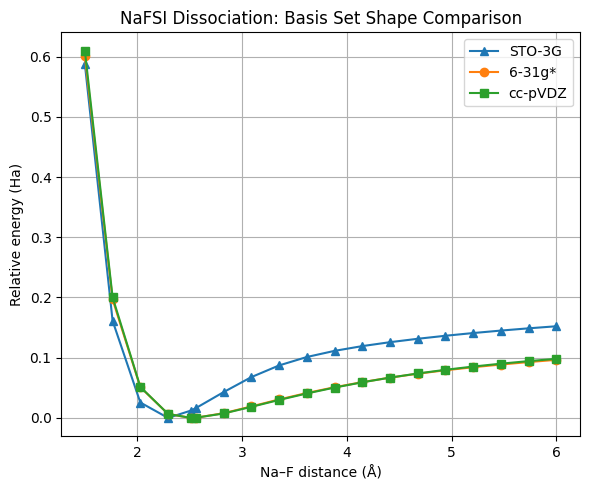

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# --- Settings ---
distances_sto3g = np.array(sorted(set(np.append(np.linspace(1.5, 6.0, 18), [2.5117]))))
distances_631g = np.array(sorted(set(np.append(np.linspace(1.5, 6.0, 18), [2.5117]))))
distances_ccpvdz = np.array(sorted(set(np.append(np.linspace(1.5, 6.0, 18), [2.5117]))))  # reduced grid for cc-pVDZ
basis_sets = {'sto3g': distances_sto3g, '631g*': distances_631g, 'cc-pVDZ': distances_ccpvdz}
energies_basis = {}

def vqe_energy_basis(geom: str, basis: str, n_active_elec=2, n_active_orb=2, active_indices=[4,5], maxiter=6000):
    driver = PySCFDriver(atom=geom, basis=basis, unit=DistanceUnit.ANGSTROM)
    problem = driver.run()
    remove_orbs = list(range(53, problem.num_spatial_orbitals))
    fc = FreezeCoreTransformer(freeze_core=False, remove_orbitals=list(range(0,45)) + remove_orbs)
    problem_red = fc.transform(problem)
    ast = ActiveSpaceTransformer(num_electrons=n_active_elec, num_spatial_orbitals=n_active_orb, active_orbitals=active_indices)
    problem_act = ast.transform(problem_red)
    mapper = JordanWignerMapper()
    init_state = HartreeFock(n_active_orb, problem_act.num_particles, mapper)
    ansatz = UCCSD(n_active_orb, problem_act.num_particles, mapper, initial_state=init_state)
    vqe = VQE(Estimator(), ansatz=ansatz, optimizer=COBYLA(maxiter=maxiter), initial_point=[0.0] * ansatz.num_parameters)
    solver = GroundStateEigensolver(mapper, vqe)
    res = solver.solve(problem_act)
    return res.total_energies[0].real

for basis, dists in basis_sets.items():
    print(f"\nRunning VQE dissociation curve for basis: {basis}")
    energies = []
    for d in dists:
        geom = (
            f"N  0.0000  0.0000  0.2798; "
            f"S  0.0000  1.4406 -0.4595; "
            f"O  1.2581  1.8123 -1.0595; "
            f"O -1.2581  1.8123 -1.0595; "
            f"F  0.0000  2.2257  1.0569; "
            f"S  0.0000 -1.4406 -0.4595; "
            f"O  1.2581 -1.8123 -1.0595; "
            f"O -1.2581 -1.8123 -1.0595; "
            f"F  0.0000 -2.2257  1.0569; "
            f"Na 0.0000  0.0000  {d:6.4f}"
        )
        e = vqe_energy_basis(geom, basis)
        energies.append(e)
        print(f"  Na–F = {d:.2f} Å : E = {e:.6f} Ha")
    energies_basis[basis] = np.array(energies)

# Normalize each curve to its minimum value for better shape comparison
energies_shifted = {}
for basis, energies in energies_basis.items():
    energies_shifted[basis] = energies - np.min(energies)

# --- Plot normalized comparison ---
plt.figure(figsize=(6, 5))
plt.plot(distances_sto3g, energies_shifted['sto3g'], '^-', label='STO-3G')
plt.plot(distances_631g, energies_shifted['631g*'], 'o-', label='6-31g*')
plt.plot(distances_ccpvdz, energies_shifted['cc-pVDZ'], 's-', label='cc-pVDZ')

plt.xlabel('Na–F distance (Å)')
plt.ylabel('Relative energy (Ha)')
plt.title('NaFSI Dissociation: Basis Set Shape Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("NaFSI_dissociation_basis_shape_aligned.png", dpi=300)
plt.show()

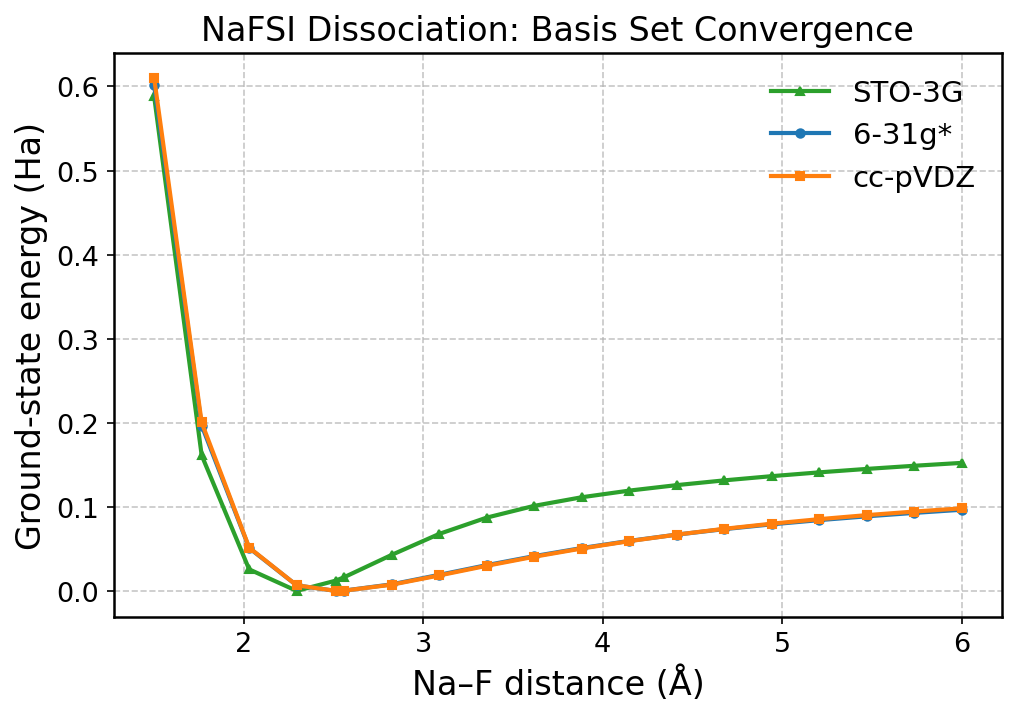

Publication-quality plot saved as NaFSI_dissociation_basis_convergence.png


In [3]:
# Publication-quality dissociation curve plot for basis set convergence
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'legend.fontsize': 14,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'axes.linewidth': 1.2,
    'lines.linewidth': 2,
    'legend.frameon': False,
    'figure.dpi': 150
})

plt.figure(figsize=(7,5))
plt.plot(distances_sto3g, energies_shifted['sto3g'], label='STO-3G', color='#2ca02c', marker='^', markersize=4)
plt.plot(distances_631g, energies_shifted['631g*'], label='6-31g*', color='#1f77b4', marker='o', markersize=4)
plt.plot(distances_ccpvdz, energies_shifted['cc-pVDZ'], label='cc-pVDZ', color='#ff7f0e', marker='s', markersize=4)
plt.xlabel('Na–F distance (Å)')
plt.ylabel('Ground-state energy (Ha)')
plt.title('NaFSI Dissociation: Basis Set Convergence')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('NaFSI_dissociation_basis_convergence.png', dpi=600, bbox_inches='tight')
plt.show()

print('Publication-quality plot saved as NaFSI_dissociation_basis_convergence.png')

Na–F = 1.50 Å | HF = -1508.945818 | FCI = -1508.946775 | VQE = -1508.945826
Na–F = 1.76 Å | HF = -1509.355441 | FCI = -1509.359650 | VQE = -1509.355443
Na–F = 2.03 Å | HF = -1509.504280 | FCI = -1509.514934 | VQE = -1509.504281
Na–F = 2.29 Å | HF = -1509.549145 | FCI = -1509.567577 | VQE = -1509.549147
Na–F = 2.56 Å | HF = -1509.555454 | FCI = -1509.582185 | VQE = -1509.555455
Na–F = 2.82 Å | HF = -1509.548404 | FCI = -1509.583494 | VQE = -1509.548406
Na–F = 3.09 Å | HF = -1509.537419 | FCI = -1509.580685 | VQE = -1509.537420
Na–F = 3.35 Å | HF = -1509.525942 | FCI = -1509.577026 | VQE = -1509.525943
Na–F = 3.62 Å | HF = -1509.515153 | FCI = -1509.573565 | VQE = -1509.515154
Na–F = 3.88 Å | HF = -1509.505373 | FCI = -1509.570554 | VQE = -1509.505373
Na–F = 4.15 Å | HF = -1509.496627 | FCI = -1509.568001 | VQE = -1509.496627
Na–F = 4.41 Å | HF = -1509.488844 | FCI = -1509.565851 | VQE = -1509.488844
Na–F = 4.68 Å | HF = -1509.481941 | FCI = -1509.564054 | VQE = -1509.481941
Na–F = 4.94 

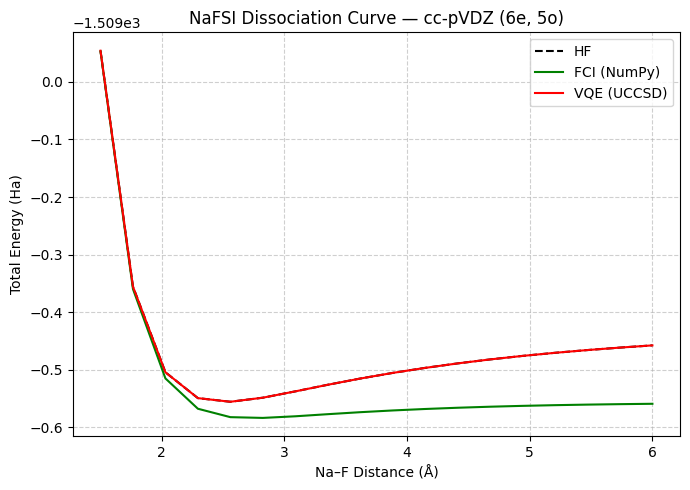

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# === Settings ===
basis = 'cc-pVDZ'
distances = np.linspace(1.5, 6.0, 18)

# === Storage ===
energies_hf = []
energies_fci = []
energies_vqe = []

# === Loop over distances ===
for d in distances:
    geom = (
        f"N  0.0000  0.0000  0.2798; "
        f"S  0.0000  1.4406 -0.4595; "
        f"O  1.2581  1.8123 -1.0595; "
        f"O -1.2581  1.8123 -1.0595; "
        f"F  0.0000  2.2257  1.0569; "
        f"S  0.0000 -1.4406 -0.4595; "
        f"O  1.2581 -1.8123 -1.0595; "
        f"O -1.2581 -1.8123 -1.0595; "
        f"F  0.0000 -2.2257  1.0569; "
        f"Na 0.0000  0.0000  {d:6.4f}"
    )

    # --- Build Qiskit Nature problem ---
    driver = PySCFDriver(atom=geom, basis=basis, unit=DistanceUnit.ANGSTROM)
    problem = driver.run()

    # --- Freeze/Remove orbitals ---
    remove_orbs = list(range(53, problem.num_spatial_orbitals))
    fc = FreezeCoreTransformer(freeze_core=False, remove_orbitals=list(range(0, 45)) + remove_orbs)
    problem_red = fc.transform(problem)

    # --- Active space: 2 electrons in 2 orbitals (indices 4 and 5) ---
    ast = ActiveSpaceTransformer(num_electrons=6, num_spatial_orbitals=5, active_orbitals=[2, 3, 4, 5, 6])
    problem_act = ast.transform(problem_red)

    mapper = JordanWignerMapper()

    # --- HF ---
    energies_hf.append(problem_act.reference_energy)

    # --- FCI (NumPy exact eigensolver) ---
    fci_solver = GroundStateEigensolver(mapper, NumPyMinimumEigensolver())
    fci_result = fci_solver.solve(problem_act)
    energies_fci.append(fci_result.total_energies[0].real)

    # --- VQE with UCCSD ansatz ---
    init_state = HartreeFock(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper)
    ansatz = UCCSD(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper, initial_state=init_state)
    #ansatz = EfficientSU2(num_qubits=problem_act.num_spin_orbitals, reps=2)
    #ansatz = TwoLocal(num_qubits=problem_act.num_spin_orbitals,
                                     #rotation_blocks='ry', entanglement_blocks='cz',
                                     #reps=2, entanglement='full')

    vqe = VQE(Estimator(), ansatz=ansatz, optimizer=COBYLA(maxiter=6000), initial_point=[0.0] * ansatz.num_parameters)
    solver = GroundStateEigensolver(mapper, vqe)
    vqe_result = solver.solve(problem_act)
    energies_vqe.append(vqe_result.total_energies[0].real)

    # --- Report ---
    print(f"Na–F = {d:.2f} Å | HF = {energies_hf[-1]:.6f} | FCI = {energies_fci[-1]:.6f} | VQE = {energies_vqe[-1]:.6f}")

# === Plot: Absolute Energies ===
plt.figure(figsize=(7, 5))
plt.plot(distances, energies_hf, 'k--', label='HF')
plt.plot(distances, energies_fci, 'g-', label='FCI (NumPy)')
plt.plot(distances, energies_vqe, 'r-', label='VQE (UCCSD)')

plt.xlabel('Na–F Distance (Å)')
plt.ylabel('Total Energy (Ha)')
plt.title('NaFSI Dissociation Curve — cc-pVDZ (6e, 5o)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.savefig("NaPF6_ccpvdz_dissociation_HF_VQE_FCI.png", dpi=600)
plt.show()

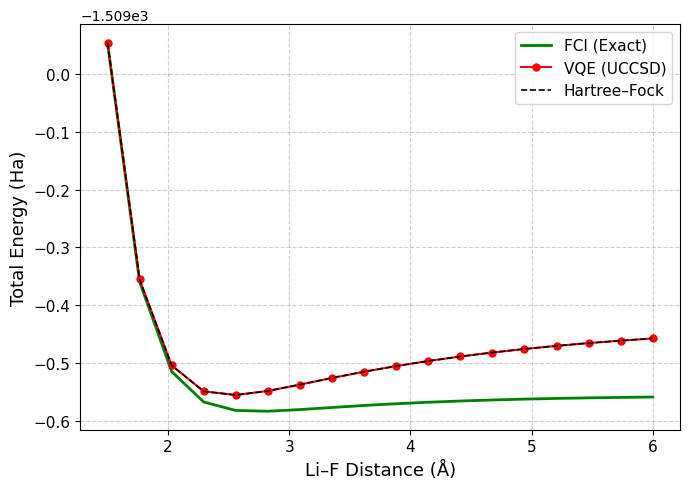

In [2]:
# === Plot: Publication-Quality Dissociation Curve ===
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))

# Plot lines
plt.plot(distances, energies_fci, 'g-', label='FCI (Exact)', linewidth=2.0)
plt.plot(distances, energies_vqe, 'ro-', label='VQE (UCCSD)', markersize=5, linewidth=1.5)
plt.plot(distances, energies_hf, 'k--', label='Hartree–Fock', linewidth=1.2)

# Axes
plt.xlabel('Li–F Distance (Å)', fontsize=13)
plt.ylabel('Total Energy (Ha)', fontsize=13)
#plt.title('NaPF₆ Dissociation Curve (cc-pVDZ, 2e in 2o)', fontsize=14)

# Grid, legend, layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()

# Save high-res image
plt.savefig("NaFSI_dissociation_VQE_vs_FCI_UCCSD.jpg", dpi=600)
plt.show()

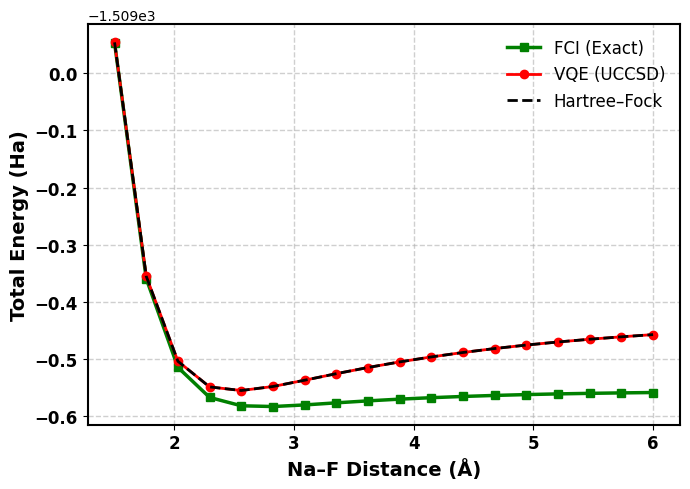

In [5]:
import matplotlib.pyplot as plt

# === Create Figure ===
plt.figure(figsize=(7, 5))

# === Plot Lines with Enhanced Style ===
plt.plot(distances, energies_fci, color='green', linestyle='-', label='FCI (Exact)', linewidth=2.5, marker='s', markersize=6)
plt.plot(distances, energies_vqe, color='red', linestyle='-', marker='o', label='VQE (UCCSD)', linewidth=2, markersize=6)
plt.plot(distances, energies_hf, color='black', linestyle='--', label='Hartree–Fock', linewidth=2)

# === Axis Labels (Bold + Readable Font) ===
plt.xlabel('Na–F Distance (Å)', fontsize=14, fontweight='bold')
plt.ylabel('Total Energy (Ha)', fontsize=14, fontweight='bold')

# === Axis Tick Styling ===
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# === Grid and Legend ===
plt.grid(True, linestyle='--', linewidth=1, alpha=0.6)
plt.legend(fontsize=12, frameon=False)

# === Axis Border Thickness ===
ax = plt.gca()
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# === Final Layout and Save ===
plt.tight_layout()
plt.savefig("NaFSI_dissociation_VQE_vs_FCI_UCCSD.jpg", dpi=600, bbox_inches='tight')  # .tiff recommended for print
plt.show()


/tmp/ipykernel_1219856/336261175.py:71: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  vqe = VQE(Estimator(), ansatz=ansatz, optimizer=COBYLA(maxiter=6000), initial_point=[0.0] * ansatz.num_parameters)


converged SCF energy = -1508.94581767672
CASCI E = -1508.94582588388  E(CI) = -6.88952527028550  S^2 = 0.0000000
Li–F = 1.50 Å | HF = -1508.945818 | FCI = -1508.946775 | VQE = -1508.945826 | CASCI = -1508.945826
converged SCF energy = -1509.3554414689
CASCI E = -1509.35544299696  E(CI) = -7.10269715480399  S^2 = 0.0000000
Li–F = 1.76 Å | HF = -1509.355441 | FCI = -1509.359650 | VQE = -1509.355443 | CASCI = -1509.355443
converged SCF energy = -1509.50428010726
CASCI E = -1509.50428123509  E(CI) = -7.08662026507795  S^2 = 0.0000000
Li–F = 2.03 Å | HF = -1509.504280 | FCI = -1509.514934 | VQE = -1509.504281 | CASCI = -1509.504281
converged SCF energy = -1509.54914539326
CASCI E = -1509.54914653004  E(CI) = -7.05108346315774  S^2 = 0.0000000
Li–F = 2.29 Å | HF = -1509.549145 | FCI = -1509.567577 | VQE = -1509.549146 | CASCI = -1509.549147
converged SCF energy = -1509.55545390943
CASCI E = -1509.55545510312  E(CI) = -7.01580908267624  S^2 = 0.0000000
Li–F = 2.56 Å | HF = -1509.555454 | FCI 

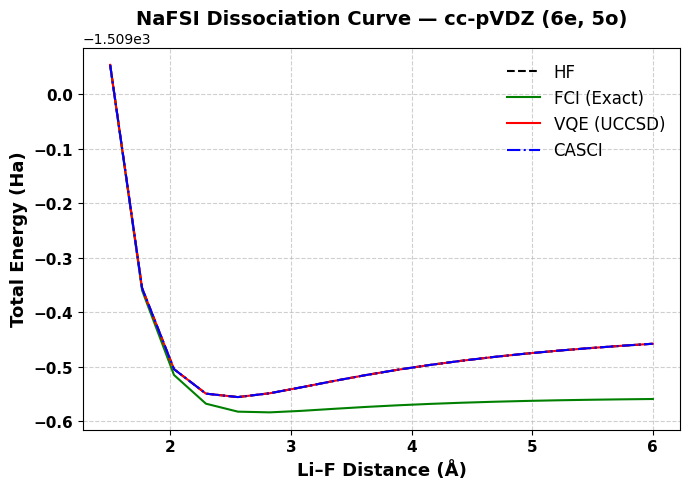

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# === Additional imports for CASCI ===
import pyscf 
from pyscf import gto, scf, mcscf
from pyscf.lib import logger

# === Settings ===
basis = 'cc-pVDZ'
distances = np.linspace(1.5, 6.0, 18)

# === Storage ===
energies_hf = []
energies_fci = []
energies_vqe = []
energies_casci = []

# === Loop over distances ===
for d in distances:
    # --- Geometry for Qiskit and PySCF ---
    geom_str = (
        f"N  0.0000  0.0000  0.2798; "
        f"S  0.0000  1.4406 -0.4595; "
        f"O  1.2581  1.8123 -1.0595; "
        f"O -1.2581  1.8123 -1.0595; "
        f"F  0.0000  2.2257  1.0569; "
        f"S  0.0000 -1.4406 -0.4595; "
        f"O  1.2581 -1.8123 -1.0595; "
        f"O -1.2581 -1.8123 -1.0595; "
        f"F  0.0000 -2.2257  1.0569; "
        f"Na 0.0000  0.0000  {d:6.4f}"
    )

    # --- Qiskit Driver ---
    driver = PySCFDriver(atom=geom_str, basis=basis, unit=DistanceUnit.ANGSTROM)
    problem = driver.run()

    # --- Freeze and reduce orbitals ---
    remove_orbs = list(range(53, problem.num_spatial_orbitals))
    fc = FreezeCoreTransformer(freeze_core=False, remove_orbitals=list(range(0, 45)) + remove_orbs)
    problem_red = fc.transform(problem)

    # --- Active space: 6 electrons in 5 orbitals ---
    ast = ActiveSpaceTransformer(num_electrons=6, num_spatial_orbitals=5, active_orbitals=[2, 3, 4, 5, 6])
    problem_act = ast.transform(problem_red)

    mapper = JordanWignerMapper()

    # --- HF ---
    energies_hf.append(problem_act.reference_energy)

    # --- FCI (exact) ---
    fci_solver = GroundStateEigensolver(mapper, NumPyMinimumEigensolver())
    fci_result = fci_solver.solve(problem_act)
    energies_fci.append(fci_result.total_energies[0].real)

    # --- VQE ---
    init_state = HartreeFock(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper)
    ansatz = UCCSD(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper, initial_state=init_state)
    vqe = VQE(Estimator(), ansatz=ansatz, optimizer=COBYLA(maxiter=6000), initial_point=[0.0] * ansatz.num_parameters)
    solver = GroundStateEigensolver(mapper, vqe)
    vqe_result = solver.solve(problem_act)
    energies_vqe.append(vqe_result.total_energies[0].real)

    # === CASCI Energy ===
    mol = pyscf.gto.Mole()
    mol.atom = geom_str
    mol.basis = basis
    mol.spin = 0
    mol.charge = 0
    mol.unit = 'Angstrom'
    mol.build()

    mf = pyscf.scf.RHF(mol).run()
    mo_occ = mf.mo_occ
    homo_idx = int(np.max(np.where(mo_occ > 0)))
    lumo_idx = homo_idx + 1

    active_orbs = list(range(max(homo_idx - 2, 0), min(homo_idx + 3, mf.mo_coeff.shape[1])))
    n_active_elec = int(np.sum(mo_occ[active_orbs]))
    nelec = ((n_active_elec + mol.spin) // 2, (n_active_elec - mol.spin) // 2)

    cas = mcscf.CASCI(mf, len(active_orbs), nelec)
    mo = cas.sort_mo(active_orbs)
    cas.kernel()
    energies_casci.append(cas.e_tot)

    # --- Report ---
    print(f"Li–F = {d:.2f} Å | HF = {energies_hf[-1]:.6f} | FCI = {energies_fci[-1]:.6f} | VQE = {energies_vqe[-1]:.6f} | CASCI = {energies_casci[-1]:.6f}")

# === Plot: Absolute Energies ===
plt.figure(figsize=(7, 5))
plt.plot(distances, energies_hf, 'k--', label='HF')
plt.plot(distances, energies_fci, 'g-', label='FCI (Exact)')
plt.plot(distances, energies_vqe, 'r-', label='VQE (UCCSD)')
plt.plot(distances, energies_casci, 'b-.', label='CASCI')

plt.xlabel('Li–F Distance (Å)', fontsize=13, fontweight='bold')
plt.ylabel('Total Energy (Ha)', fontsize=13, fontweight='bold')
plt.title('NaFSI Dissociation Curve — cc-pVDZ (6e, 5o)', fontsize=14, fontweight='bold')
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, frameon=False)
plt.tight_layout()

# Save plot if needed
# plt.savefig("LiPF6_dissociation_HF_VQE_FCI_CASCI.png", dpi=600)
plt.show()


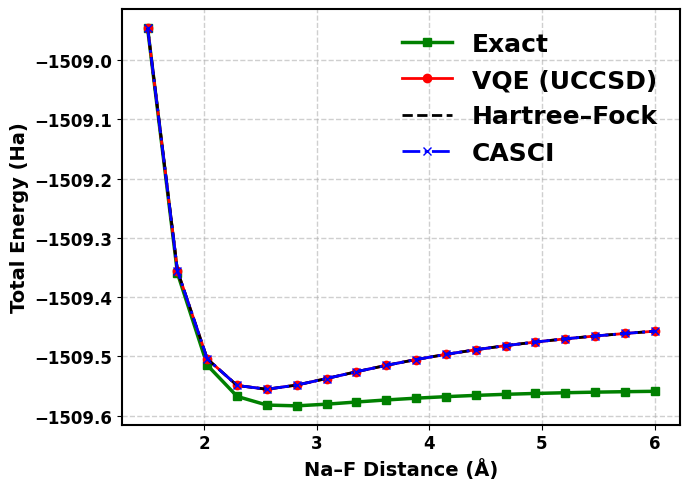

In [7]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# === Create Figure ===
plt.figure(figsize=(7, 5))

# === Plot Lines with Enhanced Style ===
plt.plot(distances, energies_fci, color='green', linestyle='-', label='Exact', linewidth=2.5, marker='s', markersize=6)
plt.plot(distances, energies_vqe, color='red', linestyle='-', marker='o', label='VQE (UCCSD)', linewidth=2, markersize=6)
plt.plot(distances, energies_hf, color='black', linestyle='--', label='Hartree–Fock', linewidth=2)
plt.plot(distances, energies_casci, color='blue', linestyle='-.', label='CASCI', linewidth=2, marker='x', markersize=6)

# === Axis Labels (Bold + Readable Font) ===
plt.xlabel('Na–F Distance (Å)', fontsize=14, fontweight='bold')
plt.ylabel('Total Energy (Ha)', fontsize=14, fontweight='bold')

# === Axis Tick Styling ===
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# === Grid and Legend ===
plt.grid(True, linestyle='--', linewidth=1, alpha=0.6)
plt.legend(prop=FontProperties(weight='bold', size=18), frameon=False)


# === Axis Border Thickness ===
ax = plt.gca()
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# === IMPORTANT FIX: disable scientific offset ===
ax.ticklabel_format(axis='y', style='plain', useOffset=False)

# === Final Layout and Save ===
plt.tight_layout()
plt.savefig("NaFSI_dissociation_VQE_vs_FCI_UCCSD.jpg", dpi=600, bbox_inches='tight')  # .tiff recommended for print
plt.show()


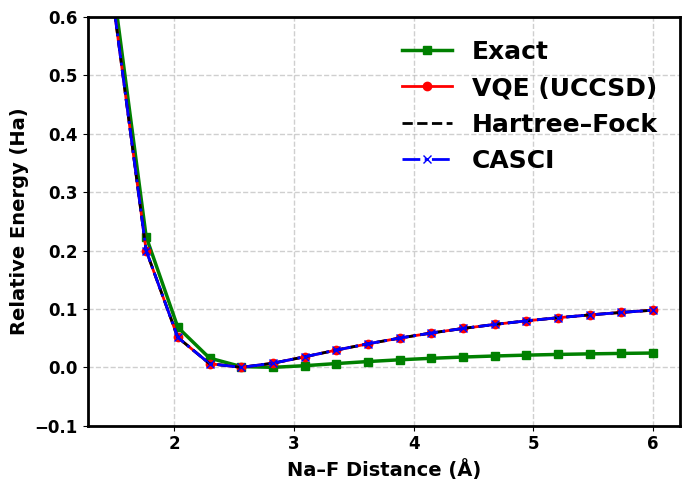

In [11]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import numpy as np

# === Convert to relative energies (key fix) ===
rel_fci   = energies_fci   - np.min(energies_fci)
rel_vqe   = energies_vqe   - np.min(energies_vqe)
rel_hf    = energies_hf    - np.min(energies_hf)
rel_casci = energies_casci - np.min(energies_casci)

# === Create Figure ===
plt.figure(figsize=(7, 5))

# === Plot relative dissociation curves ===
plt.plot(distances, rel_fci,
         color='green', linestyle='-', linewidth=2.5,
         marker='s', markersize=6, label='Exact')

plt.plot(distances, rel_vqe,
         color='red', linestyle='-', linewidth=2,
         marker='o', markersize=6, label='VQE (UCCSD)')

plt.plot(distances, rel_hf,
         color='black', linestyle='--', linewidth=2,
         label='Hartree–Fock')

plt.plot(distances, rel_casci,
         color='blue', linestyle='-.', linewidth=2,
         marker='x', markersize=6, label='CASCI')

# === Axis Labels ===
plt.xlabel('Na–F Distance (Å)', fontsize=14, fontweight='bold')
plt.ylabel('Relative Energy (Ha)', fontsize=14, fontweight='bold')

# === FIXED energy scale (consistent across all panels) ===
plt.ylim(-0.1, 0.6)

# === Axis Tick Styling ===
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# === Grid and Legend ===
plt.grid(True, linestyle='--', linewidth=1, alpha=0.6)
plt.legend(prop=FontProperties(weight='bold', size=18), frameon=False)

# === Axis Border Thickness ===
ax = plt.gca()
ax.spines['top'].set_linewidth(2.0)
ax.spines['right'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.spines['bottom'].set_linewidth(2.0)

# === IMPORTANT FIX: disable scientific offset ===
ax.ticklabel_format(axis='y', style='plain', useOffset=False)

# === Final Layout and Save ===
plt.tight_layout()
plt.savefig("NaFSI_dissociation_relative_energy.jpg",
            dpi=600, bbox_inches='tight')
plt.show()


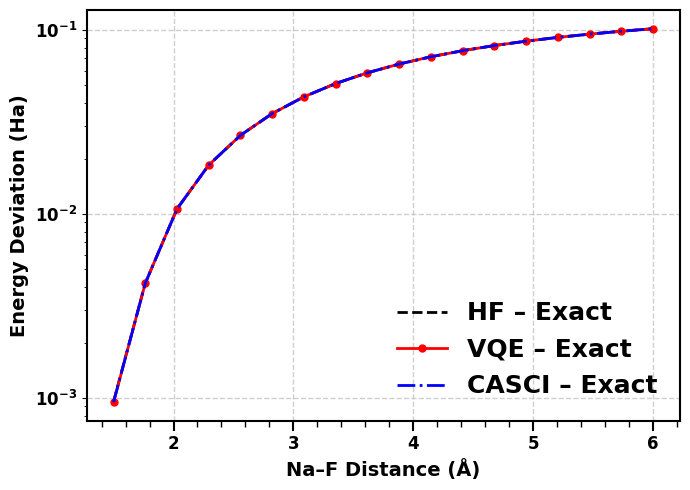

In [11]:
# === Compute Energy Deviations from FCI ===
from matplotlib.font_manager import FontProperties
import matplotlib.ticker as ticker

errors_hf = [abs(e_hf - e_fci) for e_hf, e_fci in zip(energies_hf, energies_fci)]
errors_vqe = [abs(e_vqe - e_fci) for e_vqe, e_fci in zip(energies_vqe, energies_fci)]
errors_casci = [abs(e_casci - e_fci) for e_casci, e_fci in zip(energies_casci, energies_fci)]

# === Plot: Energy Deviation from FCI ===
plt.figure(figsize=(7, 5))

plt.plot(distances, errors_hf, 'k--', label='HF – Exact', linewidth=2)
plt.plot(distances, errors_vqe, 'r-o', label='VQE – Exact', linewidth=2, markersize=5)
plt.plot(distances, errors_casci, 'b-.', label='CASCI – Exact', linewidth=2, markersize=5)

plt.xlabel('Na–F Distance (Å)', fontsize=14, fontweight='bold')
plt.ylabel('Energy Deviation (Ha)', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# Log scale for better error visibility
plt.yscale('log')
plt.grid(True, linestyle='--', linewidth=1, alpha=0.6)
plt.legend(prop=FontProperties(weight='bold', size=18), frameon=False)

#  Minor ticks on x-axis
ax = plt.gca()
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(axis='x', which='minor', length=4, width=1)
ax.tick_params(axis='x', which='major', length=7, width=1.5)

# === Axis Border Thickness ===
ax = plt.gca()
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

#plt.title('Deviation from FCI — LiPF₆ cc-pVDZ (6e, 5o)', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save high-resolution image if needed
plt.savefig("NaFSI_energy_deviation_FCI.jpg", dpi=600, bbox_inches='tight')

plt.show()

In [1]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver, QEOM, EvaluationRule
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# ──────────────────────────────────────────────────────────────────────────────
# 1.  Geometry
# ──────────────────────────────────────────────────────────────────────────────
nafsi_geometry = (
    "N  0.0000  0.0000  0.2798; "
    "S  0.0000  1.4406 -0.4595; "
    "O  1.2581  1.8123 -1.0595; "
    "O -1.2581  1.8123 -1.0595; "
    "F  0.0000  2.2257  1.0569; "
    "S  0.0000 -1.4406 -0.4595; "
    "O  1.2581 -1.8123 -1.0595; "
    "O -1.2581 -1.8123 -1.0595; "
    "F  0.0000 -2.2257  1.0569; "
    "Na 0.0000  0.0000  2.5117"
)

driver = PySCFDriver(atom=nafsi_geometry,
                     basis='cc-pVDZ',
                     charge=0,
                     spin=0,
                     unit=DistanceUnit.ANGSTROM)
problem = driver.run()

print("── Original HF problem ─────────────────────────")
print("Spatial orbitals :", problem.num_spatial_orbitals)
print("Spin  orbitals   :", problem.num_spin_orbitals)
na, nb = problem.num_particles
print(f"Electrons        : {na+nb} ({na} α, {nb} β)\n")

# ──────────────────────────────────────────────────────────────────────────────
# 2.  Freeze‑core + trim high‑energy virtuals
# ──────────────────────────────────────────────────────────────────────────────
freeze_core     = list(range(0, 45))
remove_orbitals = list(range(53, problem.num_spatial_orbitals))

fc = FreezeCoreTransformer(freeze_core=False,
                           remove_orbitals=remove_orbitals+freeze_core)
problem_red = fc.transform(problem)

all_orbs     = set(range(problem.num_spatial_orbitals))
frozen_orbs  = set(freeze_core)
removed_orbs = set(remove_orbitals)
kept_fc      = sorted(all_orbs - frozen_orbs - removed_orbs)

print("── After FreezeCoreTransformer ────────────────")
print("Frozen orbitals   :", sorted(freeze_core))
print("Removed virtuals  :", sorted(remove_orbitals))
print("Kept orbitals     :", kept_fc)
print("Spatial orbitals  :", problem_red.num_spatial_orbitals, "\n")
na, nb = problem_red.num_particles
print(f"Electrons        : {na+nb} ({na} α, {nb} β)\n")

# ──────────────────────────────────────────────────────────────────────────────
# 3.  Active‑space reduction (6 e⁻ in 5 MOs)
# ──────────────────────────────────────────────────────────────────────────────
active_orbs_reduced = [3, 4, 5]
ast = ActiveSpaceTransformer(
    num_electrons=4,
    num_spatial_orbitals=3,
    active_orbitals=active_orbs_reduced
)
problem_act = ast.transform(problem_red)

active_original = [kept_fc[i] for i in active_orbs_reduced]

print("── Active space ───────────────────────────────")
print("Active orbitals (re‑indexed) :", active_orbs_reduced)
print("Active orbitals (original HF):", active_original)
print("Spatial orbitals              :", problem_act.num_spatial_orbitals)
na, nb = problem_act.num_particles
print(f"Electrons                     : {na+nb} ({na} α, {nb} β)\n")

# ──────────────────────────────────────────────────────────────────────────────
# 4.  Qubit mapping, ansatz, VQE + QEOM for excited states
# ──────────────────────────────────────────────────────────────────────────────
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(problem_act.second_q_ops()[0])

init_state = HartreeFock(problem_act.num_spatial_orbitals,
                         problem_act.num_particles, mapper)
ansatz = UCCSD(problem_act.num_spatial_orbitals,
               problem_act.num_particles, mapper,
               initial_state=init_state)

vqe = VQE(estimator=Estimator(),
          ansatz=ansatz,
          optimizer=COBYLA(maxiter=10000))
vqe.initial_point = [0.0] * ansatz.num_parameters

gs_solver = GroundStateEigensolver(mapper, vqe)

# --- QEOM for excited states ---
qeom_solver = QEOM(gs_solver, Estimator(), "sd", EvaluationRule.ALL)
qeom_result = qeom_solver.solve(problem_act)

print("── VQE + QEOM results ────────────────────────────────")
hartree_to_ev = 27.2114
energies = [e.real for e in qeom_result.total_energies]
ground = energies[0]
for i, e in enumerate(energies):
    label = "Ground" if i == 0 else f"Excited {i}"
    delta_e = e - ground if i > 0 else 0
    print(f"{label} state: {e:.6f} Ha", end="")
    if i > 0:
        print(f"   ΔE = {delta_e:.6f} Ha ≈ {delta_e*hartree_to_ev:.2f} eV")
    else:
        print()

── Original HF problem ─────────────────────────
Spatial orbitals : 152
Spin  orbitals   : 304
Electrons        : 100 (50 α, 50 β)

── After FreezeCoreTransformer ────────────────
Frozen orbitals   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44]
Removed virtuals  : [53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151]
Kept orbitals     : [45, 46, 47, 48, 49, 50, 51, 52]
Spatial orbitals  : 8 

Electrons        : 10 (5 α, 5 β)

── Active space ───────────────────────────────
A

In [ ]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver, QEOM, EvaluationRule
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# 1. Define NaFSI geometry
nafsi_geometry = (
    "N  0.0000  0.0000  0.2798; "
    "S  0.0000  1.4406 -0.4595; "
    "O  1.2581  1.8123 -1.0595; "
    "O -1.2581  1.8123 -1.0595; "
    "F  0.0000  2.2257  1.0569; "
    "S  0.0000 -1.4406 -0.4595; "
    "O  1.2581 -1.8123 -1.0595; "
    "O -1.2581 -1.8123 -1.0595; "
    "F  0.0000 -2.2257  1.0569; "
    "Na 0.0000  0.0000  2.5117"
)

# 2. Run PySCF driver
driver = PySCFDriver(atom=nafsi_geometry, basis='cc-pVDZ', charge=0, spin=0, unit=DistanceUnit.ANGSTROM)
problem = driver.run()

# 3. Freeze core and trim virtual orbitals
freeze_core = list(range(0, 45))
remove_orbitals = list(range(53, problem.num_spatial_orbitals))
fc = FreezeCoreTransformer(freeze_core=False, remove_orbitals=remove_orbitals + freeze_core)
problem_red = fc.transform(problem)

# 4. Active space reduction (example: 4 electrons in 3 orbitals)
active_orbs_reduced = [3, 4, 5]
ast = ActiveSpaceTransformer(num_electrons=4, num_spatial_orbitals=3, active_orbitals=active_orbs_reduced)
problem_act = ast.transform(problem_red)

# 5. Qubit mapping and ansatz
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(problem_act.second_q_ops()[0])
init_state = HartreeFock(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper)
ansatz = UCCSD(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper, initial_state=init_state)

# 6. VQE ground state calculation
vqe = VQE(estimator=Estimator(), ansatz=ansatz, optimizer=COBYLA(maxiter=10000))
vqe.initial_point = [0.0] * ansatz.num_parameters
gs_solver = GroundStateEigensolver(mapper, vqe)

# 7. QEOM for excited states
qeom_solver = QEOM(gs_solver, Estimator(), "sd", EvaluationRule.ALL)
qeom_result = qeom_solver.solve(problem_act)

# 8. Print results
hartree_to_ev = 27.2114
energies = [e.real for e in qeom_result.total_energies]
ground = energies[0]
for i, e in enumerate(energies):
    label = "Ground" if i == 0 else f"Excited {i}"
    delta_e = e - ground if i > 0 else 0
    print(f"{label} state: {e:.6f} Ha", end="")
    if i > 0:
        print(f"   ΔE = {delta_e:.6f} Ha ≈ {delta_e*hartree_to_ev:.2f} eV")
    else:
        print()

In [3]:
from qiskit_nature.second_q.algorithms import GroundStateEigensolver, QEOM, ExcitedStatesEigensolver
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.algorithms import EvaluationRule
from qiskit_nature.units import DistanceUnit
from qiskit_algorithms import NumPyEigensolver, VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit.primitives import Estimator
import numpy as np

# === Step 1: Geometry and driver ===
nafsi_geometry = (
    "N  0.0000  0.0000  0.2798; "
    "S  0.0000  1.4406 -0.4595; "
    "O  1.2581  1.8123 -1.0595; "
    "O -1.2581  1.8123 -1.0595; "
    "F  0.0000  2.2257  1.0569; "
    "S  0.0000 -1.4406 -0.4595; "
    "O  1.2581 -1.8123 -1.0595; "
    "O -1.2581 -1.8123 -1.0595; "
    "F  0.0000 -2.2257  1.0569; "
    "Na 0.0000  0.0000  2.5117"
)
driver = PySCFDriver(atom=nafsi_geometry, basis="631g", charge=0, spin=0, unit=DistanceUnit.ANGSTROM)
es_problem = driver.run()
es_problem_reduced = FreezeCoreTransformer(
    freeze_core=list(range(0, 47)),
    remove_orbitals=list(range(52, es_problem.num_spatial_orbitals))
).transform(es_problem)
es_problem_active = ActiveSpaceTransformer(
    num_electrons=6,
    num_spatial_orbitals=4
).transform(es_problem_reduced)
mapper = JordanWignerMapper()

# === Step 2: Classical exact eigensolver ===
numpy_solver = NumPyEigensolver(k=8)
numpy_excited_solver = ExcitedStatesEigensolver(mapper, numpy_solver)
numpy_results = numpy_excited_solver.solve(es_problem_active)

# === Step 3: VQE + QEOM ===
estimator = Estimator()
ansatz = UCCSD(
    es_problem_active.num_spatial_orbitals,
    es_problem_active.num_particles,
    mapper,
    initial_state=HartreeFock(
        es_problem_active.num_spatial_orbitals,
        es_problem_active.num_particles,
        mapper,
    ),
)
vqe_solver = VQE(estimator, ansatz, SLSQP())
vqe_solver.initial_point = [0.0] * ansatz.num_parameters
gse = GroundStateEigensolver(mapper, vqe_solver)
qeom_solver = QEOM(gse, estimator, "sd", EvaluationRule.ALL)
qeom_results = qeom_solver.solve(es_problem_active)

# === Step 4: Wavefunction overlap calculation ===
# Both results contain eigenstates as numpy arrays (state vectors)
# Compare ground state overlap:
# ...existing code...
# === Step 4: Wavefunction overlap calculation ===
# Try to get eigenstates from raw_result if not directly available
psi_vqe_list = getattr(qeom_results, "eigenstates", None)
if psi_vqe_list is None:
    psi_vqe_list = getattr(qeom_results.raw_result, "eigenstates", None)

psi_exact_list = getattr(numpy_results, "eigenstates", None)
if psi_exact_list is None:
    psi_exact_list = getattr(numpy_results.raw_result, "eigenstates", None)

if psi_vqe_list is not None and psi_exact_list is not None:
    overlap = np.abs(np.vdot(psi_vqe_list[0], psi_exact_list[0]))**2
    print(f"\n|<Psi_VQE|Psi_Exact>|^2 (ground state overlap): {overlap:.4f}")
    for i in range(min(len(psi_vqe_list), len(psi_exact_list))):
        ov = np.abs(np.vdot(psi_vqe_list[i], psi_exact_list[i]))**2
        print(f"State {i} overlap |<Psi_VQE|Psi_Exact>|^2: {ov:.4f}")
else:
    print("Eigenstates not available from QEOM or NumPy solver. Check Qiskit Nature version and solver settings.")
# ...existing code...

# For excited states, repeat for each state:
for i in range(min(len(qeom_results.eigenstates), len(numpy_results.eigenstates))):
    ov = np.abs(np.vdot(qeom_results.eigenstates[i], numpy_results.eigenstates[i]))**2
    print(f"State {i} overlap |<Psi_VQE|Psi_Exact>|^2: {ov:.4f}")

Eigenstates not available from QEOM or NumPy solver. Check Qiskit Nature version and solver settings.


TypeError: object of type 'NoneType' has no len()